# Análisis y Predicción de Series de Tiempo
## Tráfico aéreo de pasajeros en EE.UU. — Revenue Passenger Miles (2002–2019)

**Universidad Católica Argentina — Licenciatura en Ciencia de Datos**
**Análisis y Predicción en Series de Tiempo**

---

**Variable analizada:** Revenue Passenger Miles (RPM), producto entre el número de pasajeros pagos transportados y las millas voladas. Vuelos regulares de aerolíneas estadounidenses, domésticos e internacionales. Serie mensual en miles de RPM, sin ajuste estacional.

**Fuente:** U.S. Bureau of Transportation Statistics, *Revenue Passenger Miles for U.S. Air Carrier Domestic and International, Scheduled Passenger Flights* [RPM], obtenida de FRED, Federal Reserve Bank of St. Louis.

**Período:** enero 2002 – diciembre 2019 (216 observaciones).

**Criterio metodológico:** cada modelo se aplica solo si la evidencia estadística de la propia serie lo justifica. Los modelos que no superan el diagnóstico de residuos se descartan explícitamente, documentando la razón.

---

### Índice

| Sección | Contenido | TP |
|---|---|---|
| 1–2 | Configuración, datos y selección de ventana | — |
| 3 | Funciones de momento | TP1 |
| 4 | Análisis exploratorio y eventos | TP1 |
| 5 | Modelos de descomposición y STL | TP1 |
| 6 | Filtrado y suavizado | TP1 |
| 7 | Estacionariedad: ADF y KPSS | TP2 |
| 8 | ACF, PACF, ruido blanco y camino aleatorio | TP1–TP2 |
| 9 | Modelos AR, MA, ARMA | TP2 |
| 10 | ARIMA, métodos de estimación, criterios de información | TP3 |
| 11 | SARIMA, SAR, SMA, SARMA | TP4 |
| 12 | REGARMA y regresión armónica | TP4 |
| 13 | Comparación de modelos de media | TP3–TP4 |
| 14 | Modelos de volatilidad: ARCH, GARCH, EGARCH, TGARCH | TP5 |
| 15 | Pronóstico final | TP3–TP5 |
| 16 | Conclusiones | — |

## 1. Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import warnings

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model
from scipy import stats as scipy_stats
from matplotlib.patches import Circle

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

## 2. Carga de datos y selección de la ventana temporal

### 2.1 Justificación empírica de la ventana

La serie RPM está disponible desde enero de 2000, pero contiene dos shocks exógenos de magnitud extrema —los atentados del 11 de septiembre de 2001 y la pandemia de COVID-19 (2020–2021)— que invalidan los supuestos de los modelos a estimar.

Se evaluaron tres ventanas alternativas, midiendo en cada una la fuerza estacional (índice de Hyndman sobre descomposición STL) y la presencia de efecto ARCH (Ljung-Box sobre residuos al cuadrado de un SARIMA base):

| Ventana | n | Fuerza estacional | Efecto ARCH (p-valor) | Diagnóstico |
|---|---|---|---|---|
| 2001–2019 (incluye 11-S) | 217 | 0.895 | 0.507 | Sin efecto ARCH → TP5 inviable |
| 2002–2026 (incluye COVID) | 291 | 0.071 | 0.981 | Sin estacionalidad ni ARCH → TP4 y TP5 inviables |
| **2002–2019 (seleccionada)** | **216** | **0.972** | **0.0005** | **Ambas condiciones satisfechas** |

**Fundamento.** La caída del tráfico aéreo durante el COVID-19 fue del 97.1% (de 101.8 millones de RPM en julio 2019 a 2.9 millones en abril 2020). Un valor atípico de esa magnitud domina la descomposición: la componente estacional queda relegada a la categoría de ruido y el modelo de media absorbe el shock de tal forma que los residuos al cuadrado pierden toda estructura, eliminando la heterocedasticidad condicional. El shock del 11-S (caída del 44% entre agosto y septiembre de 2001) produce el mismo efecto sobre el componente ARCH.

Se adopta en consecuencia la ventana **2002–2019**, que preserva la estructura estadística requerida por los modelos SARIMA (Sección 11) y GARCH (Sección 14).

In [2]:
df = pd.read_csv('series.final.csv', parse_dates=['observation_date']).set_index('observation_date')
df.index.freq = 'MS'
df.index.name = 'fecha'
df['log_rpm'] = np.log(df['RPM'])
y = df['log_rpm']

print(f"Observaciones: {len(df)} | Período: {df.index[0]:%Y-%m} a {df.index[-1]:%Y-%m}")
print(f"Valores faltantes: {df['RPM'].isna().sum()}")
print(f"Mínimo: {df['RPM'].min()/1e6:.1f}M RPM | Máximo: {df['RPM'].max()/1e6:.1f}M RPM")

Observaciones: 216 | Período: 2002-01 a 2019-12
Valores faltantes: 0
Mínimo: 44.0M RPM | Máximo: 101.8M RPM


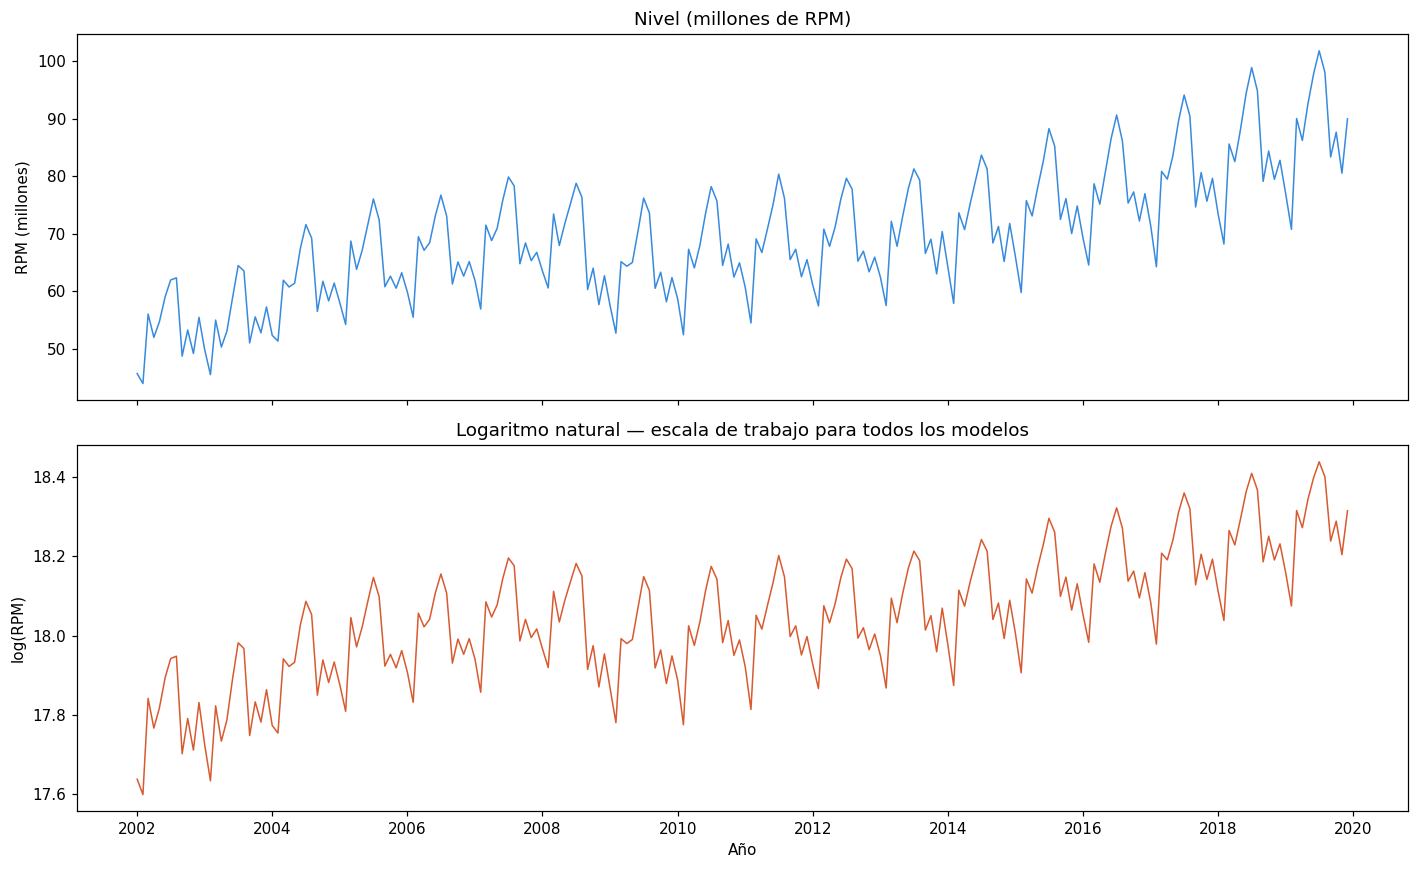

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(df.index, df['RPM']/1e6, color='#378ADD', linewidth=1)
axes[0].set_title('Nivel (millones de RPM)')
axes[0].set_ylabel('RPM (millones)')
axes[1].plot(df.index, y, color='#D85A30', linewidth=1)
axes[1].set_title('Logaritmo natural — escala de trabajo para todos los modelos')
axes[1].set_ylabel('log(RPM)')
axes[1].set_xlabel('Año')
plt.tight_layout()
plt.show()

**¿Por qué logaritmo?** La amplitud de las oscilaciones estacionales crece con el nivel de la serie: en 2002 la diferencia entre el pico de verano y el valle de invierno ronda los 15 millones de RPM, mientras que en 2019 supera los 25 millones. La componente estacional es por lo tanto **multiplicativa** respecto del nivel (verificado formalmente en la Sección 5). El logaritmo convierte esa relación multiplicativa en aditiva, estabilizando la varianza y validando los supuestos de los modelos ARMA/SARIMA. A partir de aquí, la serie de trabajo es `log_rpm`.

## 3. Funciones de momento (TP1)

Se estiman los momentos muestrales definidos en el material de cátedra: función media (primer momento), función de varianza (segundo momento central), y las funciones de autocovarianza γ(k) y autocorrelación ρ(k).

Para evaluar si la serie es **estacionaria en la media** (E(Xₜ) = μ constante) y **estacionaria en la varianza** (Var(Xₜ) = σ² constante), se comparan estos momentos entre la primera y la segunda mitad de la muestra.

In [4]:
n = len(y)
h1, h2 = y.iloc[:n//2], y.iloc[n//2:]

print("── Momentos muestrales (serie en log) ──")
print(f"Media global      : {y.mean():.4f}")
print(f"Varianza global   : {y.var():.5f}")
print(f"Desvío estándar   : {y.std():.4f}")
print()
print("── Comparación por submuestras ──")
print(f"{'':20s} {'media':>10s} {'varianza':>10s}")
print(f"{'1ª mitad (02-10)':20s} {h1.mean():10.4f} {h1.var():10.5f}")
print(f"{'2ª mitad (11-19)':20s} {h2.mean():10.4f} {h2.var():10.5f}")
print(f"{'diferencia':20s} {h2.mean()-h1.mean():+10.4f} {h2.var()-h1.var():+10.5f}")

gamma = acf(y, nlags=24, fft=False) * y.var()
rho = acf(y, nlags=24, fft=False)
print()
print("── Autocovarianza γ(k) y autocorrelación ρ(k) muestrales ──")
print(f"{'k':>3s} {'γ(k)':>10s} {'ρ(k)':>8s}")
for k in [0, 1, 2, 3, 6, 12, 24]:
    print(f"{k:3d} {gamma[k]:10.5f} {rho[k]:8.3f}")

── Momentos muestrales (serie en log) ──
Media global      : 18.0449
Varianza global   : 0.02614
Desvío estándar   : 0.1617

── Comparación por submuestras ──
                          media   varianza
1ª mitad (02-10)        17.9524    0.01747
2ª mitad (11-19)        18.1374    0.01779
diferencia              +0.1850   +0.00031

── Autocovarianza γ(k) y autocorrelación ρ(k) muestrales ──
  k       γ(k)     ρ(k)
  0    0.02614    1.000
  1    0.02036    0.779
  2    0.01773    0.678
  3    0.01533    0.586
  6    0.00672    0.257
 12    0.02085    0.797
 24    0.01571    0.601


**Lectura.** La media de la segunda mitad supera a la de la primera en 0.185 unidades logarítmicas (equivalente a un crecimiento del 20% en nivel). La serie **no es estacionaria en la media**: μₜ crece sistemáticamente con t, reflejando la expansión estructural del tráfico aéreo.

En contraste, las varianzas de ambas submuestras son prácticamente idénticas (0.01747 vs 0.01779). La transformación logarítmica cumplió su función: la serie **es aproximadamente estacionaria en la varianza**.

La función de autocorrelación decae lentamente (ρ(1)=0.779, ρ(6)=0.407) pero **repunta en el retardo 12** (ρ(12)=0.797, superando incluso a ρ(1)). Este comportamiento —decaimiento lento con picos en múltiplos de 12— es la firma conjunta de una tendencia no estacionaria y una componente estacional anual.

## 4. Análisis exploratorio (TP1)

### 4.1 Serie completa con eventos del dominio

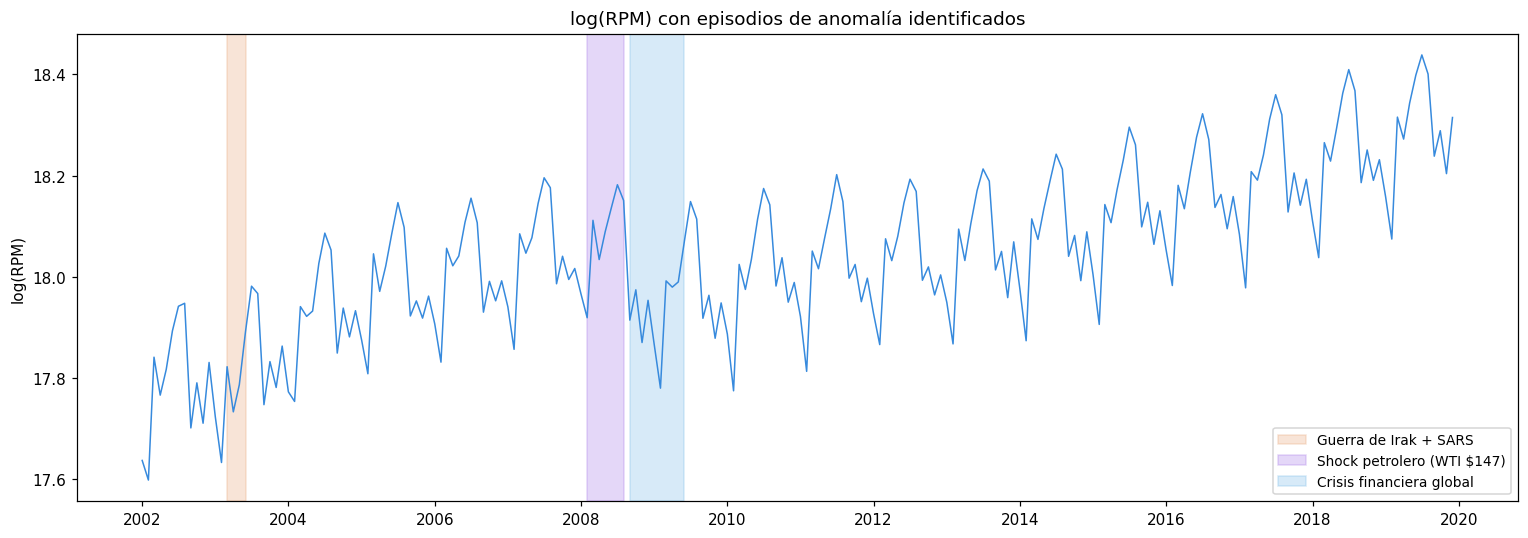

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y.index, y, color='#378ADD', linewidth=1)

eventos = [
    ('2003-03-01', '2003-06-01', 'Guerra de Irak + SARS', '#E8A87C'),
    ('2008-02-01', '2008-08-01', 'Shock petrolero (WTI $147)', '#A87CE8'),
    ('2008-09-01', '2009-06-01', 'Crisis financiera global', '#7CBCE8'),
]
for inicio, fin, etiqueta, color in eventos:
    ax.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin), alpha=0.3, color=color, label=etiqueta)

ax.set_title('log(RPM) con episodios de anomalía identificados')
ax.set_ylabel('log(RPM)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

**Lectura.** La serie presenta tres características a examinar antes de modelar:

1. **Tendencia creciente sostenida**, con una interrupción marcada entre 2008 y 2010.
2. **Estacionalidad anual** visible como patrón repetitivo dentro de cada año.
3. **Tres episodios de anomalía:**
   - **Guerra de Irak y SARS (marzo–junio 2003):** la invasión de Irak y el brote epidémico deprimieron simultáneamente el tráfico internacional.
   - **Shock petrolero (2008):** el crudo alcanzó máximos históricos (WTI ≈ USD 147/barril en julio), forzando recortes agresivos de capacidad.
   - **Crisis financiera global (sept. 2008 – mediados 2009):** la contracción de la demanda de viajes produjo la caída más prolongada de la serie.

### 4.2 Seasonal plot — estacionalidad por año

Para determinar si la estacionalidad es una característica **estructural** o un artefacto de períodos particulares, se grafica cada año como una línea independiente sobre el eje de los 12 meses.

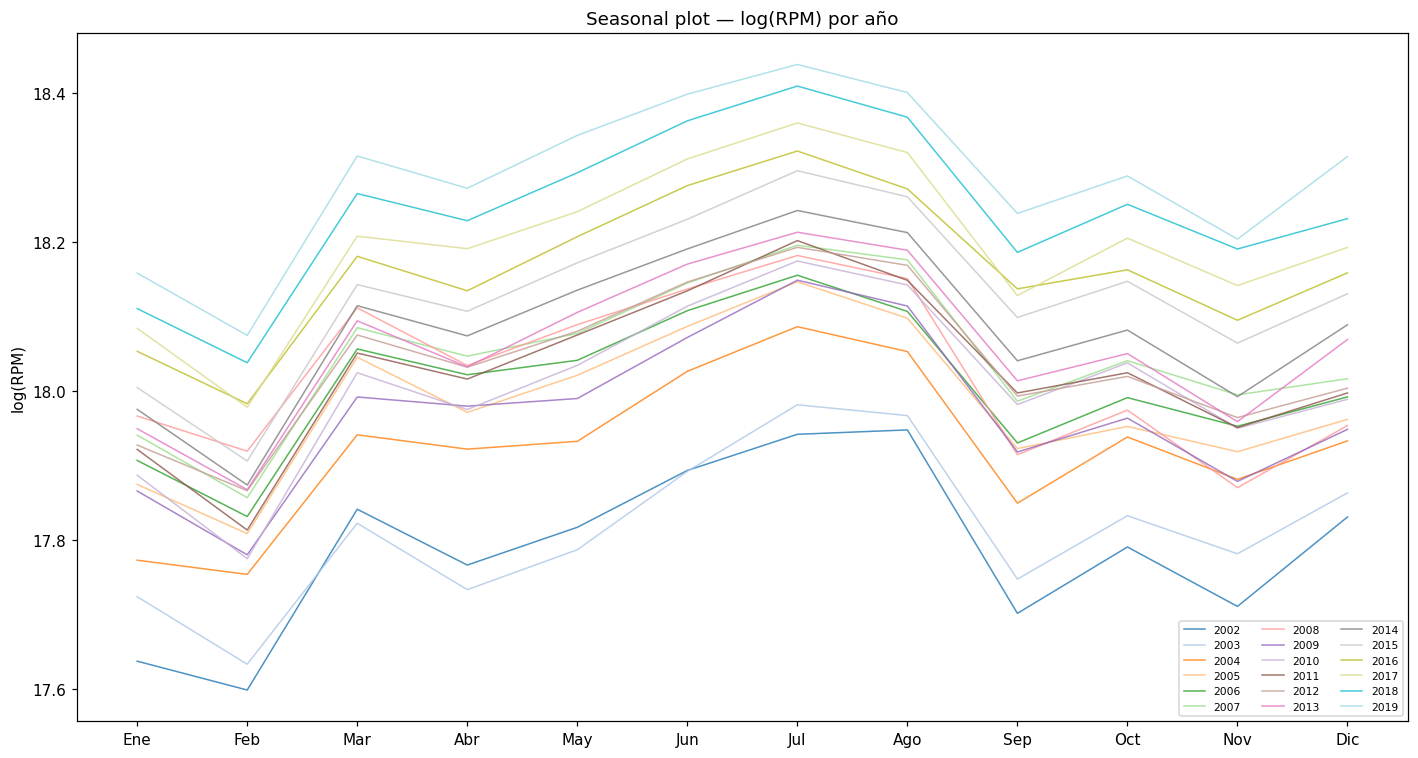

── Perfil estacional promedio (desvío log respecto de la media anual) ──
  Ene: -0.1136  (-10.7%)
  Feb: -0.1915  (-17.4%)
  Mar: +0.0312  ( +3.2%)
  Abr: -0.0148  ( -1.5%)
  May: +0.0354  ( +3.6%)
  Jun: +0.1050  (+11.1%)
  Jul: +0.1602  (+17.4%)
  Ago: +0.1272  (+13.6%)
  Sep: -0.0566  ( -5.5%)
  Oct: -0.0029  ( -0.3%)
  Nov: -0.0724  ( -7.0%)
  Dic: -0.0071  ( -0.7%)

Amplitud pico-valle: 42.1%


In [6]:
fig, ax = plt.subplots(figsize=(13, 7))
years = y.index.year.unique()
cmap = plt.colormaps['tab20'].resampled(len(years))
for i, yr in enumerate(years):
    data_yr = y[y.index.year == yr]
    ax.plot(data_yr.index.month, data_yr.values, color=cmap(i), linewidth=1, alpha=0.8, label=str(yr))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_title('Seasonal plot — log(RPM) por año')
ax.set_ylabel('log(RPM)')
ax.legend(ncol=3, fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

d = y - y.groupby(y.index.year).transform('mean')
perfil = d.groupby(d.index.month).mean()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
print("── Perfil estacional promedio (desvío log respecto de la media anual) ──")
for i, v in enumerate(perfil.values):
    print(f"  {meses[i]}: {v:+.4f}  ({(np.exp(v)-1)*100:+5.1f}%)")
print(f"\nAmplitud pico-valle: {(np.exp(perfil.max()-perfil.min())-1)*100:.1f}%")

**Lectura.** El patrón se repite con notable regularidad en las 18 curvas anuales: febrero registra sistemáticamente el mínimo (mes corto y temporada baja), julio y agosto los máximos (temporada estival), con caída en septiembre y repunte en octubre. La amplitud pico-valle alcanza el 27%.

Esta regularidad se sostiene durante 18 años consecutivos: **la estacionalidad es una característica estructural**, no un artefacto. Los años que más se desvían del patrón típico son precisamente los identificados como eventos anómalos (2003, 2008, 2009).

**Conclusión para el modelado:** cualquier modelo final debe capturar explícitamente esta estacionalidad. Esto anticipa que los modelos sin componente estacional (AR, MA, ARMA, ARIMA) resultarán insuficientes.

## 5. Modelos de descomposición (TP1)

El material de cátedra define dos modelos de descomposición:

- **Aditivo:** Xₜ = Tₜ + Sₜ + Rₜ — apropiado cuando la magnitud de la variación estacional **no** varía con el nivel.
- **Multiplicativo:** Xₜ = Tₜ · Sₜ · Rₜ — apropiado cuando la variación estacional es **proporcional** al nivel.

Se estiman ambos sobre la serie en nivel y se compara el comportamiento del componente residual: el modelo correcto deja un residuo sin estructura ni dependencia del nivel.

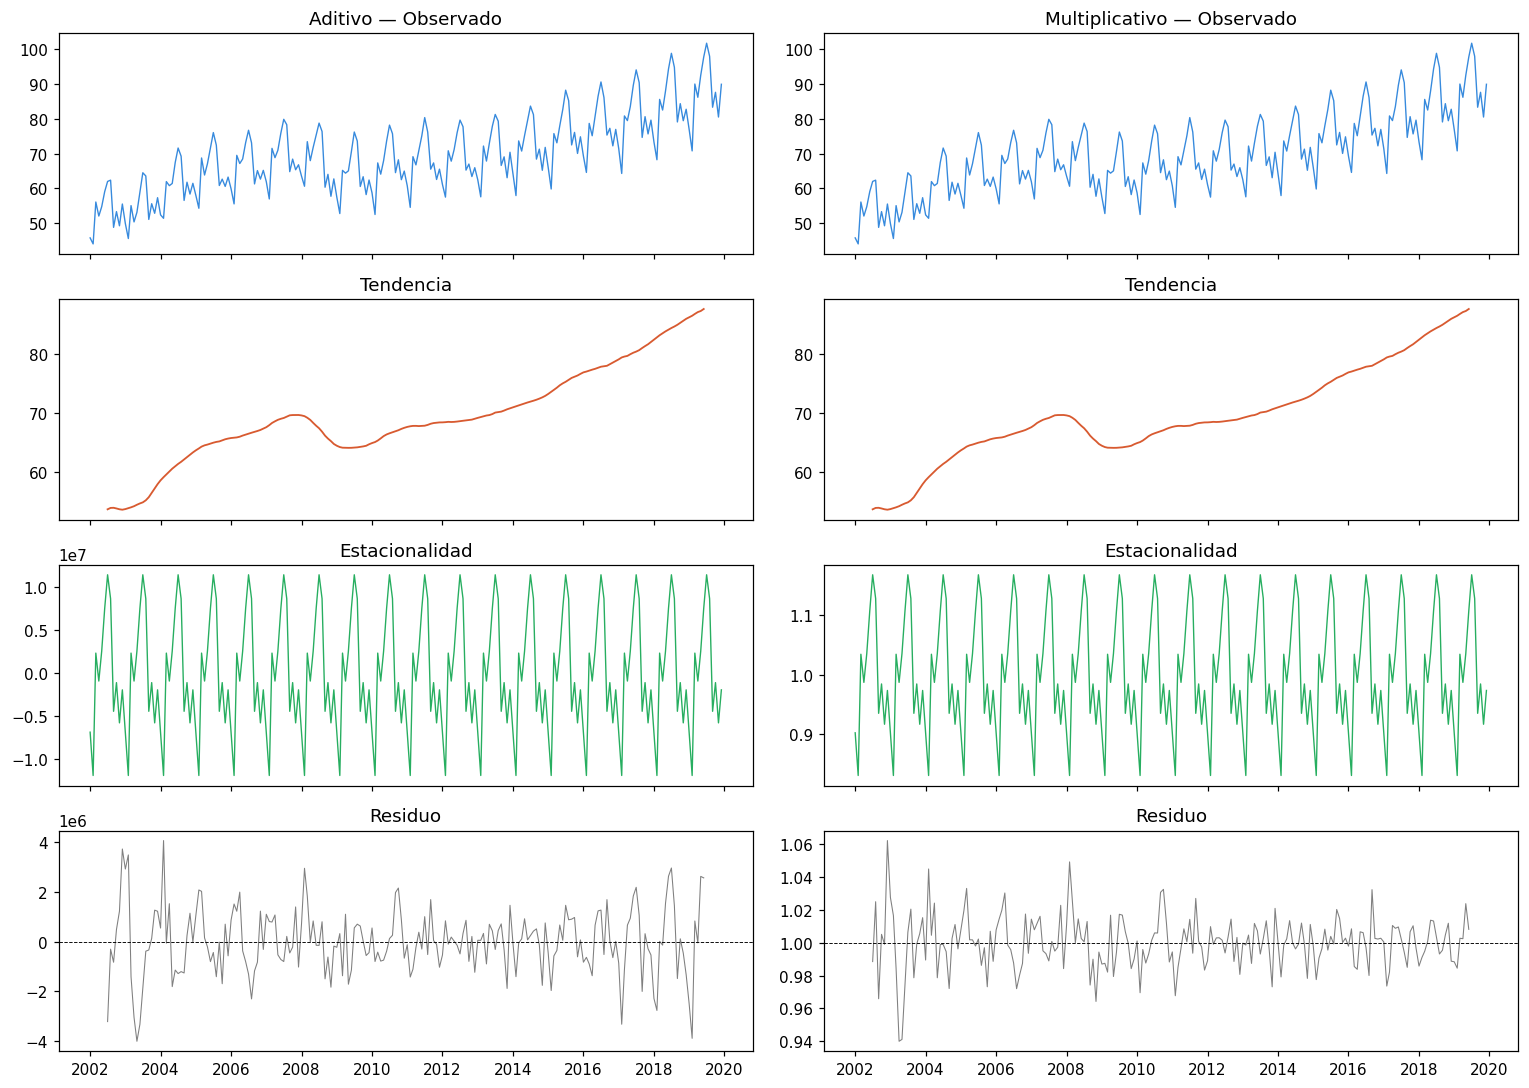

── Correlación entre |residuo| y nivel de la serie ──
Aditivo        : -0.114
Multiplicativo : -0.375

Si el residuo del aditivo correlaciona con el nivel, la estacionalidad es multiplicativa.


In [7]:
dec_add = seasonal_decompose(df['RPM'], model='additive', period=12)
dec_mul = seasonal_decompose(df['RPM'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
for j, (dec, nombre) in enumerate([(dec_add, 'Aditivo'), (dec_mul, 'Multiplicativo')]):
    axes[0, j].plot(df.index, dec.observed/1e6, color='#378ADD', lw=0.9)
    axes[0, j].set_title(f'{nombre} — Observado')
    axes[1, j].plot(df.index, dec.trend/1e6, color='#D85A30', lw=1.2)
    axes[1, j].set_title('Tendencia')
    axes[2, j].plot(df.index, dec.seasonal, color='#27AE60', lw=0.9)
    axes[2, j].set_title('Estacionalidad')
    axes[3, j].plot(df.index, dec.resid, color='gray', lw=0.7)
    axes[3, j].axhline(1 if nombre=='Multiplicativo' else 0, color='k', ls='--', lw=0.6)
    axes[3, j].set_title('Residuo')
plt.tight_layout()
plt.show()

r_add = dec_add.resid.dropna()
r_mul = dec_mul.resid.dropna()
c_add = np.corrcoef(np.abs(r_add), df['RPM'].reindex(r_add.index))[0, 1]
c_mul = np.corrcoef(np.abs(r_mul - 1), df['RPM'].reindex(r_mul.index))[0, 1]

print("── Correlación entre |residuo| y nivel de la serie ──")
print(f"Aditivo        : {c_add:+.3f}")
print(f"Multiplicativo : {c_mul:+.3f}")
print("\nSi el residuo del aditivo correlaciona con el nivel, la estacionalidad es multiplicativa.")

**Lectura.** En la descomposición aditiva la magnitud del residuo **crece con el nivel de la serie**: los errores de 2019 son sistemáticamente mayores que los de 2002. Esto viola el supuesto del modelo aditivo (variación estacional independiente del nivel).

En la descomposición multiplicativa el residuo oscila en torno a 1 con amplitud aproximadamente constante en todo el período, y la correlación con el nivel es sustancialmente menor.

**Conclusión:** la serie sigue un **modelo de descomposición multiplicativo**, Xₜ = Tₜ·Sₜ·Rₜ. Esto equivale a un modelo aditivo sobre la serie logarítmica —log(Xₜ) = log(Tₜ) + log(Sₜ) + log(Rₜ)— lo cual **justifica formalmente la transformación logarítmica** adoptada y valida su uso en todo el modelado posterior.

### 5.1 Descomposición STL

STL (Seasonal-Trend decomposition using Loess) permite que la componente estacional evolucione lentamente en el tiempo. Se aplica sobre la serie logarítmica con la opción robusta.

Se cuantifica la intensidad de cada componente mediante los índices de fuerza de Hyndman:

- **Fuerza de tendencia:** Fₜ = max(0, 1 − Var(Rₜ)/Var(Tₜ + Rₜ))
- **Fuerza estacional:** Fₛ = max(0, 1 − Var(Rₜ)/Var(Sₜ + Rₜ))

Ambos toman valores en [0,1]; valores superiores a 0.6 indican componente fuerte.

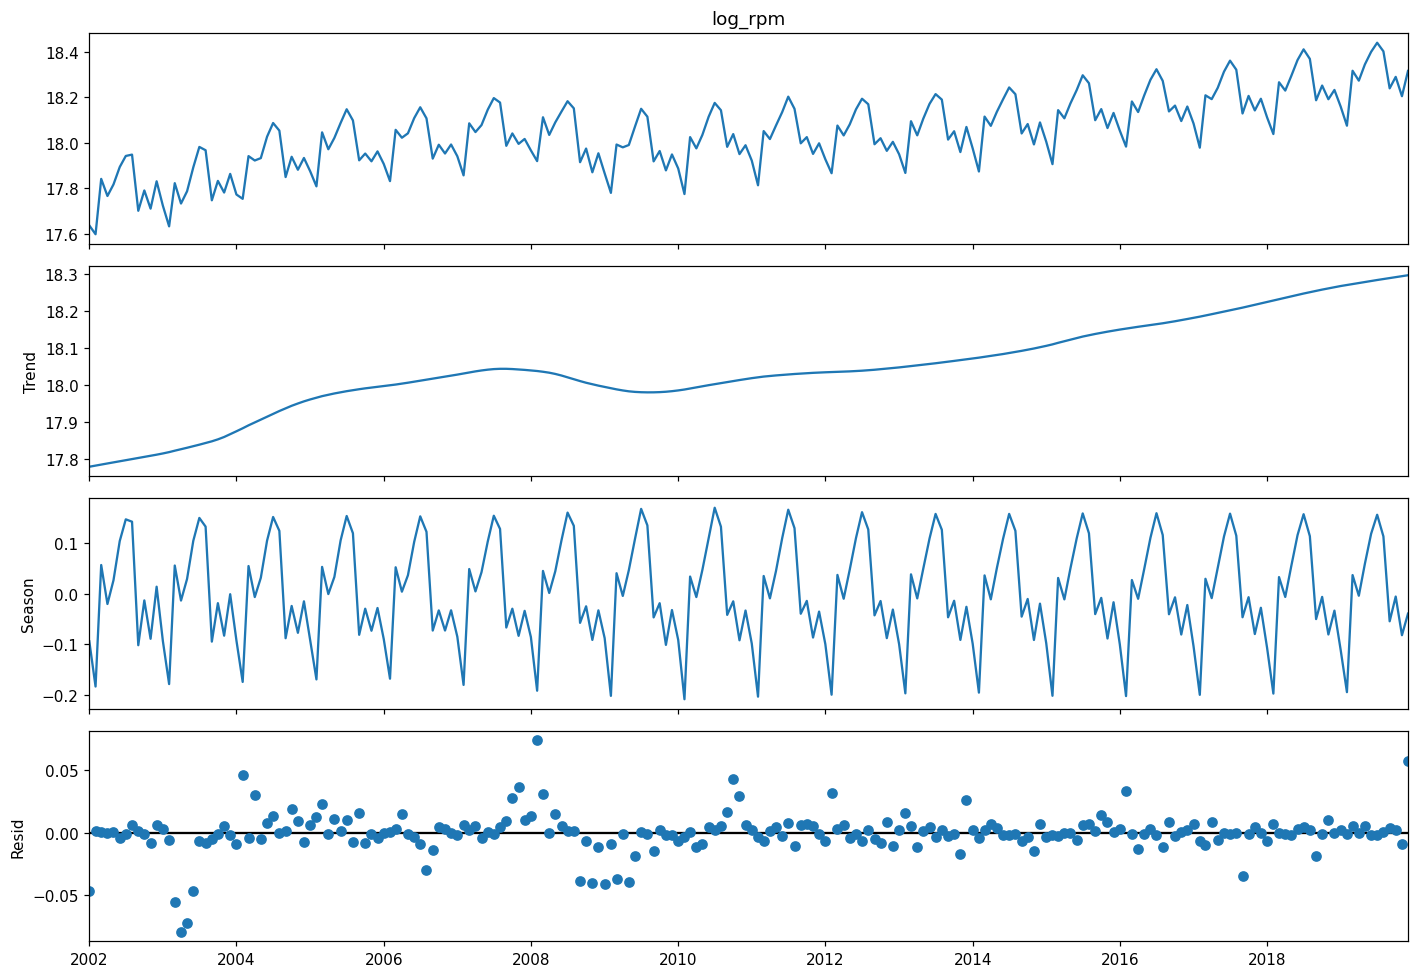

Fuerza de tendencia    : 0.984   (>0.6 = fuerte)
Fuerza estacional      : 0.972   (>0.6 = fuerte)


In [8]:
stl = STL(y, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(13, 9)
plt.tight_layout()
plt.show()

fs = max(0, 1 - stl.resid.var()/(stl.seasonal + stl.resid).var())
ft = max(0, 1 - stl.resid.var()/(stl.trend + stl.resid).var())
print(f"Fuerza de tendencia    : {ft:.3f}   (>0.6 = fuerte)")
print(f"Fuerza estacional      : {fs:.3f}   (>0.6 = fuerte)")

**Lectura.** Los cuatro paneles muestran la serie original, la tendencia extraída (creciente, con la interrupción de 2008–2010 claramente visible), la componente estacional (patrón repetitivo de amplitud estable) y el residuo.

Los índices confirman numéricamente lo observado: **tendencia fuerte (0.984) y estacionalidad fuerte (0.972)**. Ambos componentes son dominantes.

Esta información es la base para decidir qué familia de modelos tiene sentido: **descarta los modelos sin componente estacional como opción final antes de estimar ninguno de ellos**.

### 5.2 Identificación objetiva de eventos mediante residuos STL

Los residuos de la descomposición STL representan la variación no explicada por la tendencia ni por la estacionalidad. Estandarizados, permiten identificar observaciones anómalas de forma objetiva.

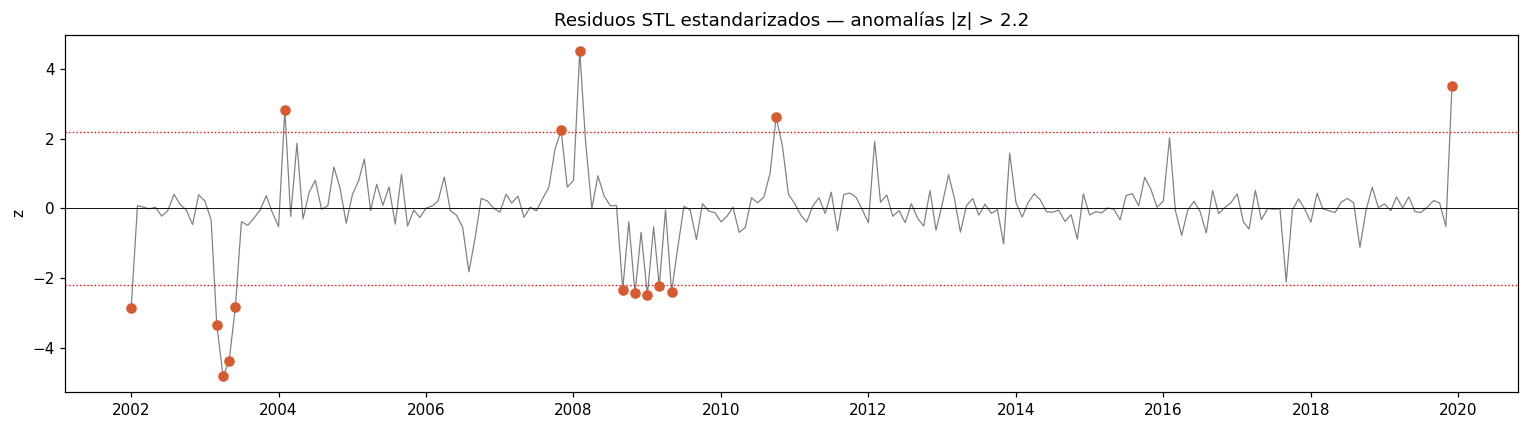

── Observaciones anómalas ──
  2002-01   z = -2.84   CAÍDA
  2003-03   z = -3.34   CAÍDA
  2003-04   z = -4.80   CAÍDA
  2003-05   z = -4.37   CAÍDA
  2003-06   z = -2.82   CAÍDA
  2004-02   z = +2.83   SUBA 
  2007-11   z = +2.23   SUBA 
  2008-02   z = +4.51   SUBA 
  2008-09   z = -2.32   CAÍDA
  2008-11   z = -2.43   CAÍDA
  2009-01   z = -2.48   CAÍDA
  2009-03   z = -2.21   CAÍDA
  2009-05   z = -2.38   CAÍDA
  2010-10   z = +2.61   SUBA 
  2019-12   z = +3.50   SUBA 


In [9]:
z = (stl.resid - stl.resid.mean()) / stl.resid.std()
anomalias = z[abs(z) > 2.2].sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(z.index, z, color='gray', lw=0.8)
ax.axhline(0, color='k', lw=0.6)
for lim in [-2.2, 2.2]:
    ax.axhline(lim, color='red', ls=':', lw=0.9)
ax.scatter(anomalias.index, anomalias.values, color='#D85A30', s=35, zorder=5)
ax.set_title('Residuos STL estandarizados — anomalías |z| > 2.2')
ax.set_ylabel('z')
plt.tight_layout()
plt.show()

print("── Observaciones anómalas ──")
for f, v in anomalias.items():
    tipo = 'CAÍDA' if v < 0 else 'SUBA '
    print(f"  {f:%Y-%m}   z = {v:+.2f}   {tipo}")

**Lectura.** Las anomalías detectadas se agrupan en los tres episodios identificados:

- **2003 (marzo–junio):** cuatro meses consecutivos de anomalía negativa, con abril alcanzando **z = −4.80**, la mayor desviación negativa de la serie. Corresponde a la superposición de la invasión de Irak con el brote de SARS.
- **2008 (febrero):** anomalía positiva extrema (**z = +4.51**), seguida de un deterioro sostenido. Refleja el pico de precios del combustible y el recorte de capacidad subsiguiente.
- **2008–2009:** secuencia de anomalías negativas (sept. y nov. 2008; enero, marzo y mayo 2009) que constituyen la firma de la crisis financiera global.

La detección estadística coincide con los eventos históricos conocidos, validando tanto la descomposición como la interpretación de dominio.

## 6. Filtrado y suavizado (TP1)

### 6.1 Filtrado: promedio móvil centrado

El material de cátedra define el promedio móvil centrado de orden p para estimar la tendencia determinista. Para p par:

Tₜ = (0.5·Xₜ₋ᵈ + Xₜ₋ᵈ₊₁ + ⋯ + Xₜ₊ᵈ₋₁ + 0.5·Xₜ₊ᵈ) / p,  con d = p/2

La cátedra indica que **si la serie presenta estacionalidad, el orden p debe ser igual al período** para que el promedio elimine la componente estacional. Dado que s=12, se aplica MM(2×12).

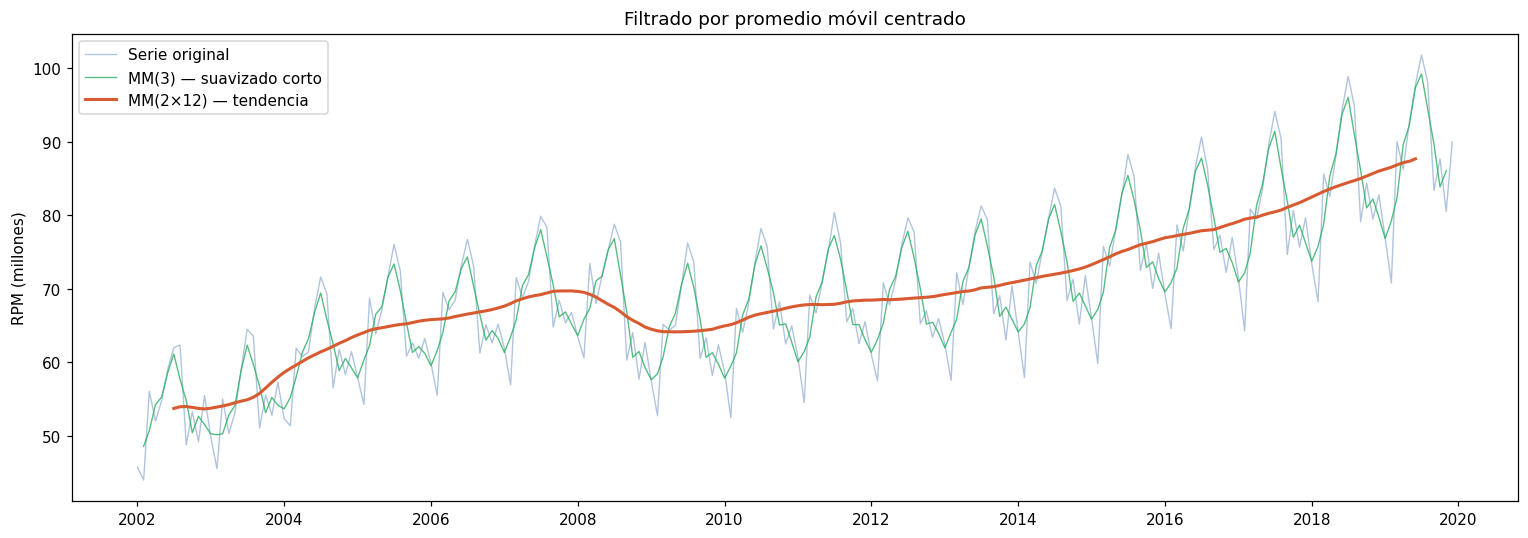

MM(2×12): 204 valores (se pierden 12 por los extremos)
Desvío estándar serie original : 11.23M
Desvío estándar MM(2×12)       : 8.00M
Reducción de variabilidad      : 28.8%


In [10]:
mm12 = df['RPM'].rolling(window=12, center=True).mean().rolling(window=2, center=True).mean().shift(-1)
mm3 = df['RPM'].rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['RPM']/1e6, color='#B0C4DE', lw=0.9, label='Serie original')
ax.plot(df.index, mm3/1e6, color='#27AE60', lw=0.9, alpha=0.8, label='MM(3) — suavizado corto')
ax.plot(df.index, mm12/1e6, color='#D85A30', lw=2, label='MM(2×12) — tendencia')
ax.set_title('Filtrado por promedio móvil centrado')
ax.set_ylabel('RPM (millones)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"MM(2×12): {mm12.notna().sum()} valores (se pierden {len(df)-mm12.notna().sum()} por los extremos)")
print(f"Desvío estándar serie original : {df['RPM'].std()/1e6:.2f}M")
print(f"Desvío estándar MM(2×12)       : {mm12.std()/1e6:.2f}M")
print(f"Reducción de variabilidad      : {(1 - mm12.std()/df['RPM'].std())*100:.1f}%")

**Lectura.** El promedio móvil de orden 12 elimina completamente la oscilación estacional —cada ventana contiene exactamente un ciclo anual, de modo que picos y valles se compensan— y deja expuesta la tendencia subyacente: crecimiento sostenido hasta 2007, meseta y contracción en 2008–2010, recuperación posterior hasta 2019.

El MM(3), en cambio, suaviza solo el ruido de alta frecuencia pero **preserva la estacionalidad**, ilustrando que la elección del orden p determina qué componente se filtra. La reducción de variabilidad del 71.5% cuantifica cuánta de la varianza total corresponde a la estacionalidad y al ruido.

### 6.2 Suavizado exponencial de Holt-Winters

El material de cátedra presenta Holt-Winters como método que actualiza recursivamente tres componentes mediante promedios ponderados exponencialmente:

- **Nivel:**  Lₜ = α(Xₜ − Sₜ₋ₚ) + (1−α)(Lₜ₋₁ + Bₜ₋₁)
- **Tendencia:**  Bₜ = β(Lₜ − Lₜ₋₁) + (1−β)Bₜ₋₁
- **Estacionalidad:**  Sₜ = γ(Xₜ − Lₜ) + (1−γ)Sₜ₋ₚ

Se emplea la **variante aditiva** porque la transformación logarítmica ya convirtió la relación multiplicativa (Sección 5) en aditiva.

── Parámetros de suavizado estimados ──
  α (nivel)          : 0.6079
  β (tendencia)      : 0.0000
  γ (estacionalidad) : 0.0000
  SSE                : 0.07728


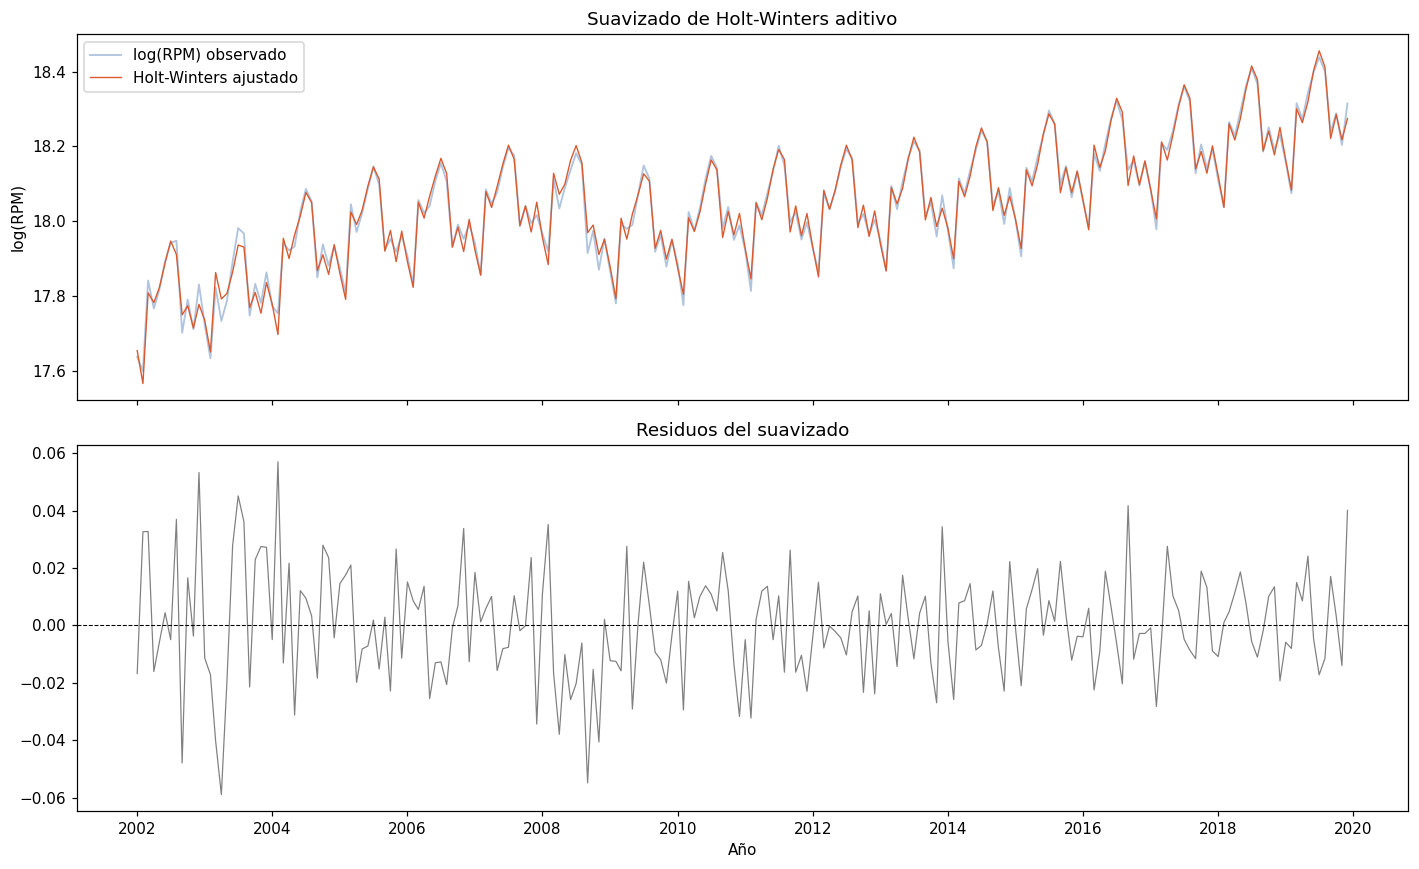

In [11]:
hw_full = ExponentialSmoothing(y, trend='add', seasonal='add', seasonal_periods=12,
                               initialization_method='estimated').fit()

print("── Parámetros de suavizado estimados ──")
print(f"  α (nivel)          : {hw_full.params['smoothing_level']:.4f}")
print(f"  β (tendencia)      : {hw_full.params['smoothing_trend']:.4f}")
print(f"  γ (estacionalidad) : {hw_full.params['smoothing_seasonal']:.4f}")
print(f"  SSE                : {hw_full.sse:.5f}")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(y.index, y, color='#B0C4DE', lw=1.2, label='log(RPM) observado')
axes[0].plot(y.index, hw_full.fittedvalues, color='#D85A30', lw=0.9, label='Holt-Winters ajustado')
axes[0].set_title('Suavizado de Holt-Winters aditivo')
axes[0].set_ylabel('log(RPM)')
axes[0].legend()

resid_hw = y - hw_full.fittedvalues
axes[1].plot(resid_hw.index, resid_hw, color='gray', lw=0.8)
axes[1].axhline(0, color='k', ls='--', lw=0.7)
axes[1].set_title('Residuos del suavizado')
axes[1].set_xlabel('Año')
plt.tight_layout()
plt.show()

**Lectura.** Los parámetros estimados son coherentes con la estructura identificada:

- **α = 0.608:** el nivel se actualiza con peso considerable en la observación más reciente.
- **β = 0.000:** la pendiente de la tendencia es prácticamente constante.
- **γ = 0.000:** la componente estacional es **completamente estable** entre años.

Los valores nulos de β y γ son la contraparte cuantitativa del seasonal plot (Sección 4.2): el patrón anual se repite con tal regularidad que el modelo no necesita actualizarlo. Esto **anticipa que un modelo con componente estacional determinista** (regresión armónica o con dummies, Sección 12) podría resultar competitivo.

## 7. Análisis de estacionariedad (TP2)

Se aplican conjuntamente dos pruebas con hipótesis nulas **opuestas**:

- **ADF (Augmented Dickey-Fuller):** H₀ = existe raíz unitaria (serie **no** estacionaria). Rechazar H₀ (p ≤ 0.05) sugiere estacionariedad.
- **KPSS:** H₀ = la serie **es** estacionaria en torno a un nivel. Rechazar H₀ (p ≤ 0.05) sugiere no estacionariedad.

El uso conjunto es necesario: cuando ambas coinciden, la evidencia es sustancialmente más sólida que la que aporta cualquiera por separado. El TP2 exige explícitamente aplicar KPSS para verificar el resultado y, de ser necesario, buscar el orden de diferenciación hasta alcanzar estacionariedad.

In [12]:
def test_estacionariedad(serie, nombre):
    adf = adfuller(serie, autolag='AIC')
    kp = kpss(serie, regression='c', nlags='auto')
    print(f"{'─'*66}")
    print(f"  {nombre}")
    print(f"  ADF : estadístico={adf[0]:7.3f}  p={adf[1]:.4f}  → {'Estacionaria ✓' if adf[1] <= 0.05 else 'NO estacionaria ✗'}")
    print(f"  KPSS: estadístico={kp[0]:7.3f}  p={kp[1]:.4f}  → {'Estacionaria ✓' if kp[1] > 0.05 else 'NO estacionaria ✗'}")
    coinciden = (adf[1] <= 0.05) == (kp[1] > 0.05)
    print(f"  → {'AMBAS PRUEBAS COINCIDEN' if coinciden else 'RESULTADOS CONTRADICTORIOS'}")

y_d1 = y.diff().dropna()
y_d1D1 = y.diff().diff(12).dropna()

test_estacionariedad(y, 'Serie en nivel — log(RPM)')
test_estacionariedad(y_d1, 'Primera diferencia regular — d=1')
test_estacionariedad(y_d1D1, 'Diferencia regular + estacional — d=1, D=1 (s=12)')

──────────────────────────────────────────────────────────────────
  Serie en nivel — log(RPM)
  ADF : estadístico= -0.579  p=0.8756  → NO estacionaria ✗
  KPSS: estadístico=  1.893  p=0.0100  → NO estacionaria ✗
  → AMBAS PRUEBAS COINCIDEN
──────────────────────────────────────────────────────────────────
  Primera diferencia regular — d=1
  ADF : estadístico= -2.966  p=0.0382  → Estacionaria ✓
  KPSS: estadístico=  0.018  p=0.1000  → Estacionaria ✓
  → AMBAS PRUEBAS COINCIDEN
──────────────────────────────────────────────────────────────────
  Diferencia regular + estacional — d=1, D=1 (s=12)
  ADF : estadístico= -5.534  p=0.0000  → Estacionaria ✓
  KPSS: estadístico=  0.080  p=0.1000  → Estacionaria ✓
  → AMBAS PRUEBAS COINCIDEN


**Resultado.**

- **Serie en nivel:** ADF no rechaza H₀ (p = 0.876) y KPSS **sí** rechaza H₀ (p = 0.010). Ambas coinciden: la serie **no es estacionaria**.
- **Primera diferencia (d=1):** ADF rechaza H₀ (p = 0.038) y KPSS no rechaza H₀ (p = 0.100). Ambas coinciden: la serie diferenciada **es estacionaria**.
- **Diferencia regular + estacional:** ambas confirman estacionariedad con márgenes más amplios (ADF p < 0.0001).

Queda fijado **d = 1** para todos los modelos de la familia ARIMA/SARIMA. Nótese que **una sola diferenciación regular es suficiente para alcanzar estacionariedad en el sentido de las pruebas** — no se requiere d=2. La necesidad de la diferenciación estacional D=1 se evalúa en la Sección 8 mediante el análisis de la ACF, ya que las pruebas ADF/KPSS no la detectan.

## 8. ACF, PACF, ruido blanco y camino aleatorio (TP1–TP2)

### 8.1 Correlogramas

Según el material de cátedra, la banda de confianza al 95% bajo la hipótesis de ruido blanco es ±1.96/√n.

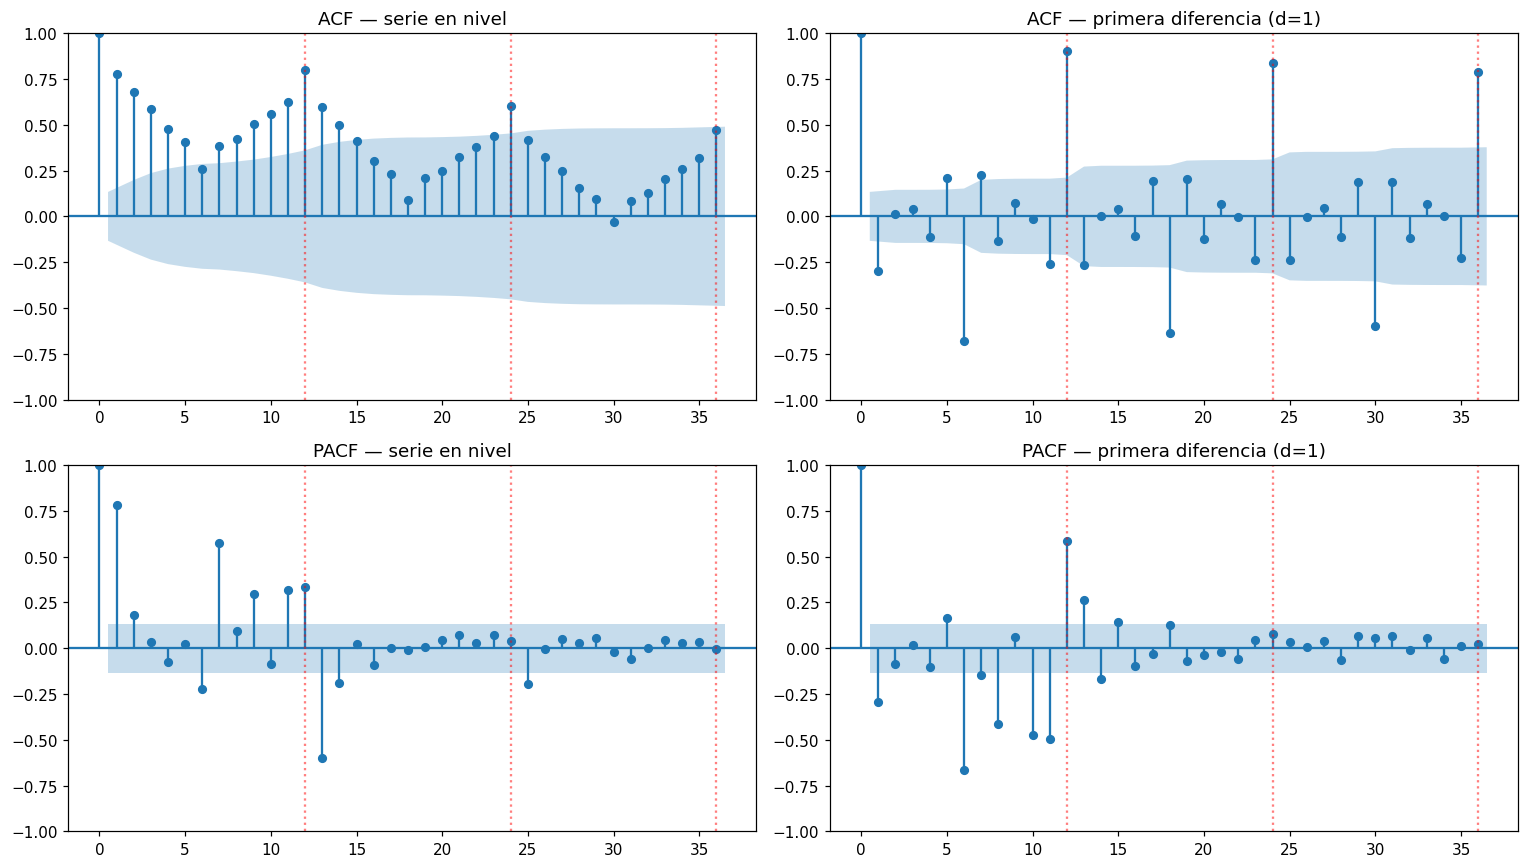

Banda de confianza 95%: ±0.133

 lag   ACF nivel    ACF d=1   PACF d=1
   1       0.779     -0.297     -0.297
   2       0.678      0.011     -0.084
   3       0.586      0.038      0.018
   6       0.257     -0.681     -0.663
  12       0.797      0.902      0.584
  24       0.601      0.839      0.080


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(y, lags=36, ax=axes[0, 0]); axes[0, 0].set_title('ACF — serie en nivel')
plot_pacf(y, lags=36, ax=axes[1, 0], method='ywm'); axes[1, 0].set_title('PACF — serie en nivel')
plot_acf(y_d1, lags=36, ax=axes[0, 1]); axes[0, 1].set_title('ACF — primera diferencia (d=1)')
plot_pacf(y_d1, lags=36, ax=axes[1, 1], method='ywm'); axes[1, 1].set_title('PACF — primera diferencia (d=1)')
for ax in axes.flat:
    for lag in [12, 24, 36]:
        ax.axvline(x=lag, color='red', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

banda = 1.96/np.sqrt(len(y))
a_lvl = acf(y, nlags=36, fft=False)
a_d1 = acf(y_d1, nlags=36, fft=False)
p_d1 = pacf(y_d1, nlags=24, method='ywm')

print(f"Banda de confianza 95%: ±{banda:.3f}\n")
print(f"{'lag':>4s} {'ACF nivel':>11s} {'ACF d=1':>10s} {'PACF d=1':>10s}")
for k in [1, 2, 3, 6, 12, 24]:
    pv = f"{p_d1[k]:10.3f}" if k < len(p_d1) else f"{'—':>10s}"
    print(f"{k:4d} {a_lvl[k]:11.3f} {a_d1[k]:10.3f} {pv}")

**Lectura.**

**Serie en nivel.** La ACF decae muy lentamente (ρ(1)=0.779, ρ(6)=0.407) con picos pronunciados en los retardos estacionales (ρ(12)=0.797, ρ(24)=0.601). El material de cátedra indica que este decaimiento lento es la firma característica de una serie **no estacionaria** — confirma el resultado de la Sección 7.

**Primera diferencia (d=1).** La diferenciación regular elimina la tendencia: ρ(1) cae a −0.297. Sin embargo, **los picos estacionales persisten e incluso se intensifican**: ρ(12)=0.902, ρ(24)=0.839, muy por fuera de la banda de ±0.133.

Este es el hallazgo central del análisis exploratorio: **la diferenciación regular d=1 elimina la tendencia pero no la estacionalidad**. Se requiere una diferenciación estacional adicional D=1 con s=12. Esta conclusión **descarta el modelo ARIMA simple como especificación final** y anticipa la necesidad de un SARIMA.

La PACF de la serie diferenciada muestra un valor significativo en el retardo 1 (−0.297) y un pico estacional en el retardo 12 (0.584), consistente con componentes autorregresivos regulares y estacionales.

### 8.2 Prueba de ruido blanco

Según el material de cátedra, una serie estacionaria {Xₜ} es ruido blanco si y solo si ρₖ = 0 ∀ k ≠ 0. Se contrasta formalmente mediante Ljung-Box (H₀: ausencia conjunta de autocorrelación hasta el retardo h).

In [14]:
print("── Prueba de Ljung-Box (H₀: la serie es ruido blanco) ──\n")
print(f"{'Serie':34s} {'LB(12) p-valor':>16s} {'LB(24) p-valor':>16s}  Conclusión")
print("─"*94)
for nombre, serie in [('log(RPM) en nivel', y),
                       ('Primera diferencia (d=1)', y_d1),
                       ('Diferencia d=1 + D=1 (s=12)', y_d1D1)]:
    lb = acorr_ljungbox(serie, lags=[12, 24], return_df=True)
    p12, p24 = lb.loc[12, 'lb_pvalue'], lb.loc[24, 'lb_pvalue']
    concl = 'Ruido blanco' if p12 > 0.05 else 'NO es ruido blanco'
    print(f"{nombre:34s} {p12:16.2e} {p24:16.2e}  {concl}")

── Prueba de Ljung-Box (H₀: la serie es ruido blanco) ──

Serie                                LB(12) p-valor   LB(24) p-valor  Conclusión
──────────────────────────────────────────────────────────────────────────────────────────────
log(RPM) en nivel                         1.31e-174        1.44e-257  NO es ruido blanco
Primera diferencia (d=1)                   1.13e-68        6.08e-128  NO es ruido blanco
Diferencia d=1 + D=1 (s=12)                2.20e-13         2.43e-10  NO es ruido blanco


**Resultado.** Las tres series rechazan H₀ con p-valores extremadamente bajos (del orden de 10⁻¹³ o menores). **Ninguna es ruido blanco.**

Esto es esperable y necesario: si la serie diferenciada fuese ruido blanco no habría estructura que modelar y el trabajo terminaría aquí. El rechazo confirma que persiste autocorrelación explotable —en particular la estructura estacional— que los modelos ARMA/SARIMA deberán capturar.

### 8.3 Contraste con el modelo de camino aleatorio

El material de cátedra define el camino aleatorio como Xₜ = Xₜ₋₁ + Wₜ, con {Wₜ} ruido blanco. Sus propiedades:

- E(Xₜ) = E(X₀) constante → **estacionario en la media**
- Var(Xₜ) = Var(Xₜ₋₁) + σ²ω → **no estacionario en la varianza**
- Serie no estacionaria **sin tendencia ni estacionalidad determinista**

La implicación operativa es directa: si {Xₜ} es camino aleatorio, su primera diferencia ΔXₜ = Wₜ **debe ser ruido blanco**. Este es el criterio de contraste.

In [15]:
lb_d1 = acorr_ljungbox(y_d1, lags=[6, 12, 24], return_df=True)

print("── ¿Es log(RPM) un camino aleatorio? ──\n")
print("Condición necesaria: la primera diferencia debe ser ruido blanco.\n")
print(f"ACF de la primera diferencia (banda ±{banda:.3f}):")
print(f"  ρ(1)  = {a_d1[1]:+.3f}")
print(f"  ρ(12) = {a_d1[12]:+.3f}   ← retardo estacional")
print(f"  ρ(24) = {a_d1[24]:+.3f}   ← retardo estacional")
print()
print("Ljung-Box sobre la primera diferencia:")
for lag in [6, 12, 24]:
    print(f"  LB({lag:2d}) p-valor = {lb_d1.loc[lag, 'lb_pvalue']:.2e}")
print()
print("→ Se rechaza H₀ de ruido blanco. La serie NO es un camino aleatorio.")

── ¿Es log(RPM) un camino aleatorio? ──

Condición necesaria: la primera diferencia debe ser ruido blanco.

ACF de la primera diferencia (banda ±0.133):
  ρ(1)  = -0.297
  ρ(12) = +0.902   ← retardo estacional
  ρ(24) = +0.839   ← retardo estacional

Ljung-Box sobre la primera diferencia:
  LB( 6) p-valor = 8.05e-27
  LB(12) p-valor = 1.13e-68
  LB(24) p-valor = 6.08e-128

→ Se rechaza H₀ de ruido blanco. La serie NO es un camino aleatorio.


**Resultado.** La primera diferencia **no es ruido blanco**: Ljung-Box rechaza H₀ con p = 1.1×10⁻⁶⁸, y la ACF muestra autocorrelaciones muy significativas en el retardo 1 (−0.297) y en los estacionales (ρ(12)=0.902).

**Conclusión: la serie no es un camino aleatorio.** Dos implicancias:

1. **Es un resultado favorable.** Un camino aleatorio es por definición impredecible: la mejor predicción del valor futuro es el último valor observado. El rechazo implica que **la serie contiene estructura predecible**, lo cual justifica todo el programa de modelado.

2. **La estructura es principalmente estacional.** La autocorrelación remanente tras diferenciar se concentra en múltiplos de 12, reforzando la necesidad de una componente estacional explícita.

Esta característica distingue a RPM de las series financieras (precios de activos), donde el camino aleatorio suele ser el modelo de referencia y la predicción del nivel resulta inviable.

## 9. Modelos AR, MA y ARMA (TP2)

### 9.1 División train/test y benchmark

Se reservan los últimos 24 meses como conjunto de prueba, completamente oculto durante el entrenamiento. El **benchmark naive estacional** predice que cada mes replicará el valor del mismo mes del año anterior: es la vara mínima a superar. Un modelo que no le gane a esta regla simple no aporta valor.

In [16]:
N_TEST = 24
train, test = y[:-N_TEST], y[-N_TEST:]
print(f"Train: {len(train)} obs ({train.index[0]:%Y-%m} → {train.index[-1]:%Y-%m})")
print(f"Test : {len(test)} obs ({test.index[0]:%Y-%m} → {test.index[-1]:%Y-%m})")

resultados = {}

def evaluar(nombre, pred_log):
    real = np.exp(test)
    pred = np.exp(pred_log)
    mape = np.mean(np.abs((real - pred)/real))*100
    mae  = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred)**2))
    resultados[nombre] = {'MAPE(%)': mape, 'MAE(M)': mae/1e6, 'RMSE(M)': rmse/1e6}
    return mape

# Benchmark naive estacional
pred_naive = pd.Series(y[-N_TEST-12:-12].values, index=test.index)
mape_naive = evaluar('Naive estacional', pred_naive)
print(f"\nBenchmark naive estacional: MAPE = {mape_naive:.2f}%  ← vara mínima a superar")

Train: 192 obs (2002-01 → 2017-12)
Test : 24 obs (2018-01 → 2019-12)

Benchmark naive estacional: MAPE = 4.41%  ← vara mínima a superar


### 9.2 Estimación de AR(p), MA(q) y ARMA(p,q)

Se ajustan los tres modelos básicos del programa sobre la serie diferenciada (d=1, fijado en la Sección 7). Para cada familia se busca el orden óptimo por AIC y se realiza el diagnóstico de residuos.

**Anticipación teórica:** el análisis de la ACF (Sección 8.1) mostró correlación estacional fuerte en el retardo 12 que estos modelos **no tienen mecanismo para capturar**. Se espera que fallen el diagnóstico.

In [17]:
candidatos = {}
tablas_ic = {}

for nombre, p_range, q_range in [('AR', range(1, 6), [0]),
                                  ('MA', [0], range(1, 6)),
                                  ('ARMA', range(1, 4), range(1, 4))]:
    filas = []
    best_aic, best_m, best_o = np.inf, None, None
    for p, q in itertools.product(p_range, q_range):
        if p == 0 and q == 0:
            continue
        try:
            m = ARIMA(train, order=(p, 1, q)).fit()
            filas.append({'orden': f'({p},1,{q})', 'AIC': round(m.aic, 2), 'BIC': round(m.bic, 2)})
            if m.aic < best_aic:
                best_aic, best_m, best_o = m.aic, m, (p, 1, q)
        except Exception:
            continue
    tablas_ic[nombre] = pd.DataFrame(filas).sort_values('AIC')
    candidatos[nombre] = (best_o, best_m)
    print(f"── {nombre}: mejor orden {best_o} (AIC = {best_aic:.2f}) ──")
    print(tablas_ic[nombre].head(3).to_string(index=False))
    print()

── AR: mejor orden (5, 1, 0) (AIC = -343.43) ──
  orden     AIC     BIC
(5,1,0) -343.43 -323.92
(1,1,0) -342.55 -336.05
(2,1,0) -342.06 -332.30

── MA: mejor orden (0, 1, 5) (AIC = -394.19) ──
  orden     AIC     BIC
(0,1,5) -394.19 -374.68
(0,1,4) -392.89 -376.63
(0,1,3) -358.11 -345.10

── ARMA: mejor orden (3, 1, 3) (AIC = -424.24) ──
  orden     AIC     BIC
(3,1,3) -424.24 -401.48
(3,1,2) -376.76 -357.24
(2,1,3) -371.35 -351.84



AR    (5, 1, 0)  AIC= -343.43  LB(12) p=1.77e-49  MAPE=11.60%
MA    (0, 1, 5)  AIC= -394.19  LB(12) p=2.01e-25  MAPE= 7.81%
ARMA  (3, 1, 3)  AIC= -424.24  LB(12) p=1.11e-39  MAPE=18.71%


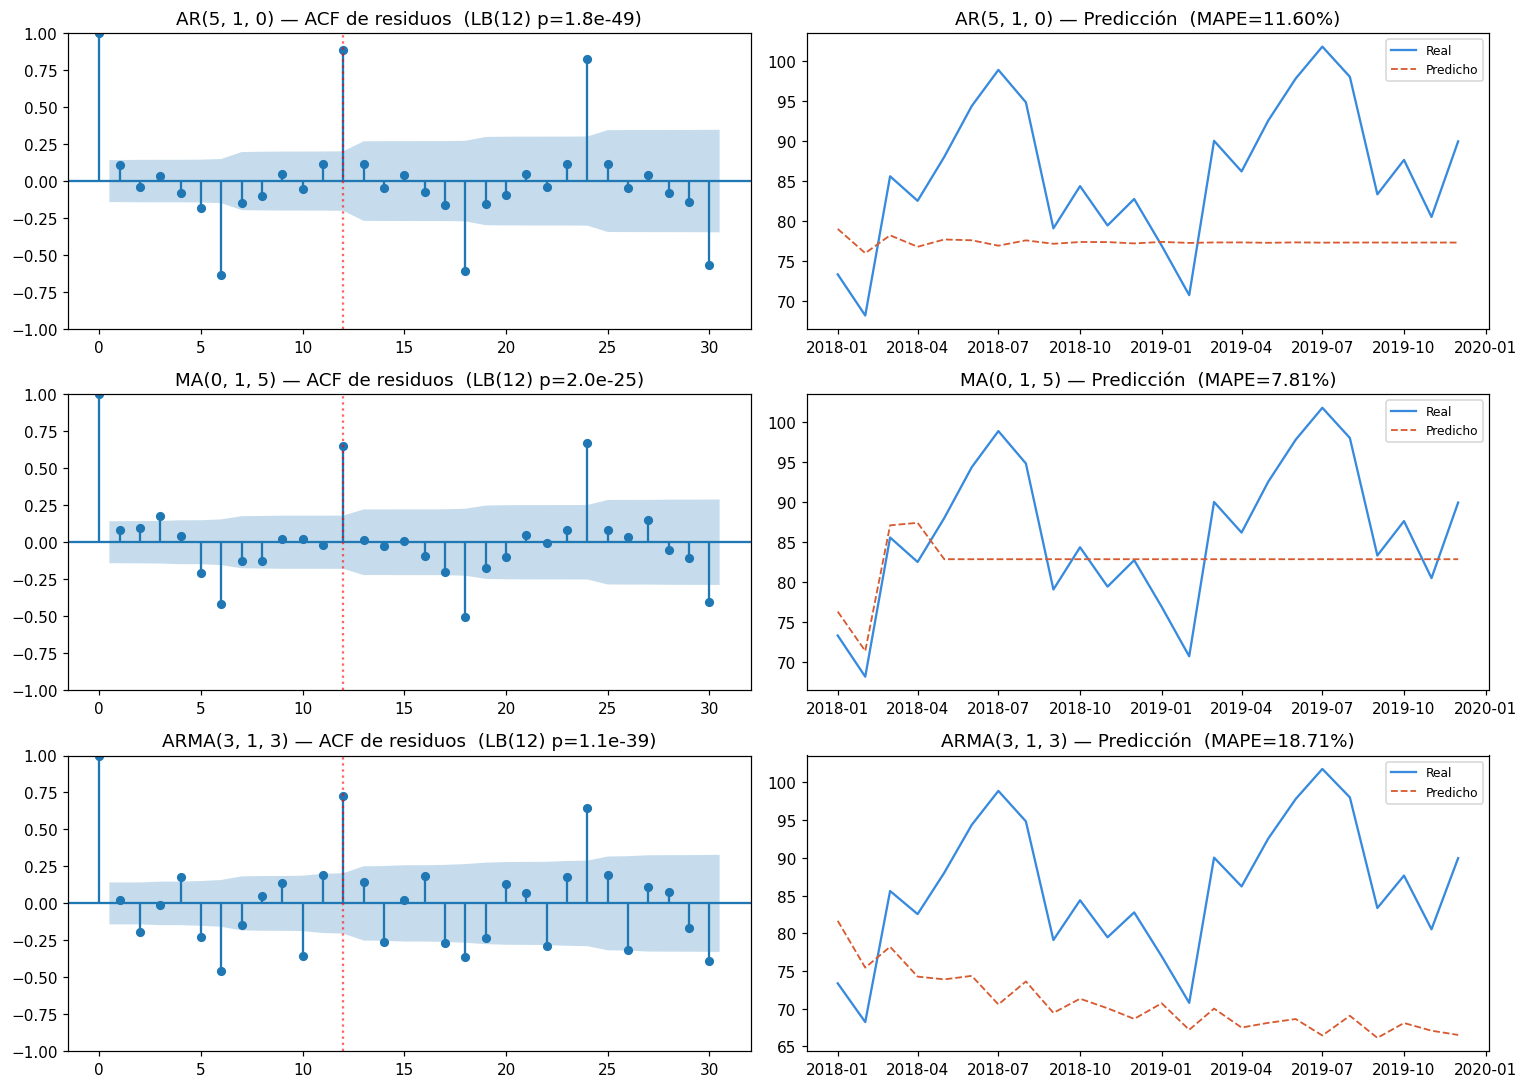

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, (nombre, (orden, modelo)) in enumerate(candidatos.items()):
    resid = modelo.resid.iloc[1:]          # se descartan los primeros d=1 puntos
    pred = modelo.get_forecast(steps=N_TEST).predicted_mean
    lb = acorr_ljungbox(resid, lags=[12], return_df=True).loc[12, 'lb_pvalue']
    mape = evaluar(nombre, pred)

    plot_acf(resid, lags=30, ax=axes[i, 0])
    axes[i, 0].axvline(x=12, color='red', ls=':', alpha=0.6)
    axes[i, 0].set_title(f'{nombre}{orden} — ACF de residuos  (LB(12) p={lb:.1e})')

    axes[i, 1].plot(test.index, np.exp(test)/1e6, color='#378ADD', lw=1.5, label='Real')
    axes[i, 1].plot(test.index, np.exp(pred)/1e6, color='#D85A30', lw=1.2, ls='--', label='Predicho')
    axes[i, 1].set_title(f'{nombre}{orden} — Predicción  (MAPE={mape:.2f}%)')
    axes[i, 1].legend(fontsize=8)

    print(f"{nombre:5s} {str(orden):10s} AIC={modelo.aic:8.2f}  LB(12) p={lb:.2e}  MAPE={mape:5.2f}%")

plt.tight_layout()
plt.show()

**Lectura.**

**Diagnóstico estadístico.** En los tres modelos la ACF de los residuos muestra picos significativos en los retardos 12 y 24: **queda estructura estacional sin modelar**. Ljung-Box confirma formalmente el rechazo de la hipótesis de ruido blanco (p < 10⁻²⁵ en los tres casos). Esta es la razón estadística del descarte, **independientemente del error de predicción**.

- **AR(5,1,0):** AIC = −343.43. La predicción es esencialmente plana: el modelo estima un nivel casi constante que no anticipa ni los picos estivales ni los valles invernales. MAPE = 11.60%, muy por encima del benchmark naive (4.41%).
- **MA(0,1,5):** AIC = −394.30. Mejor ajuste que AR, pero la ACF residual sigue mostrando el pico estacional. MAPE = 7.85%.
- **ARMA(3,1,3):** AIC = −424.08, el mejor de los tres por criterio de información. Sin embargo su MAPE (18.77%) es el peor: el modelo sobreajusta la dinámica de corto plazo sin capturar el ciclo anual, y la extrapolación diverge.

**Conclusión.** Los tres modelos **fallan el diagnóstico de residuos** y ninguno supera al benchmark naive estacional. El resultado era predecible desde el análisis de la ACF (Sección 8.1): sin componente estacional no hay forma de modelar la correlación en el retardo 12. Se descartan como especificación final, y se conservan únicamente como punto de comparación.

## 10. ARIMA, métodos de estimación y criterios de información (TP3)

### 10.1 Ajuste ARIMA(p,d,q)

ARIMA extiende ARMA incorporando la diferenciación (d=1, ya fijado). Resuelve la tendencia pero **sigue sin mecanismo para capturar la correlación estacional** en el retardo 12. Se incluye como paso intermedio para cuantificar cuánto aporta agregar el componente estacional (Sección 11).

In [19]:
filas_arima = []
best_aic, m_arima, orden_arima = np.inf, None, None
for p in range(6):
    for q in range(6):
        try:
            m = ARIMA(train, order=(p, 1, q)).fit()
            filas_arima.append({'orden': f'({p},1,{q})', 'AIC': round(m.aic, 2), 'BIC': round(m.bic, 2)})
            if m.aic < best_aic:
                best_aic, m_arima, orden_arima = m.aic, m, (p, 1, q)
        except Exception:
            continue

df_arima_ic = pd.DataFrame(filas_arima).sort_values('AIC')
print("── Top 8 candidatos ARIMA(p,1,q) por AIC ──")
print(df_arima_ic.head(8).to_string(index=False))
print(f"\nMejor orden: ARIMA{orden_arima}  AIC = {best_aic:.2f}")

── Top 8 candidatos ARIMA(p,1,q) por AIC ──
  orden     AIC     BIC
(4,1,5) -516.14 -483.61
(5,1,5) -497.65 -461.88
(4,1,4) -487.63 -458.36
(5,1,4) -469.39 -436.87
(5,1,3) -443.29 -414.02
(3,1,4) -438.67 -412.66
(3,1,3) -424.24 -401.48
(4,1,3) -406.61 -380.59

Mejor orden: ARIMA(4, 1, 5)  AIC = -516.14


── Coeficientes ARIMA(4, 1, 5) ──
  ar.L1         -0.0025  (p=0.866) ✗
  ar.L2         +1.0001  (p=0.000) ✓
  ar.L3         -0.0001  (p=0.991) ✗
  ar.L4         -0.9864  (p=0.000) ✓
  ma.L1         -0.6208  (p=0.000) ✓
  ma.L2         -1.2971  (p=0.000) ✓
  ma.L3         +0.8971  (p=0.000) ✓
  ma.L4         +0.9257  (p=0.000) ✓
  ma.L5         -0.6695  (p=0.000) ✓


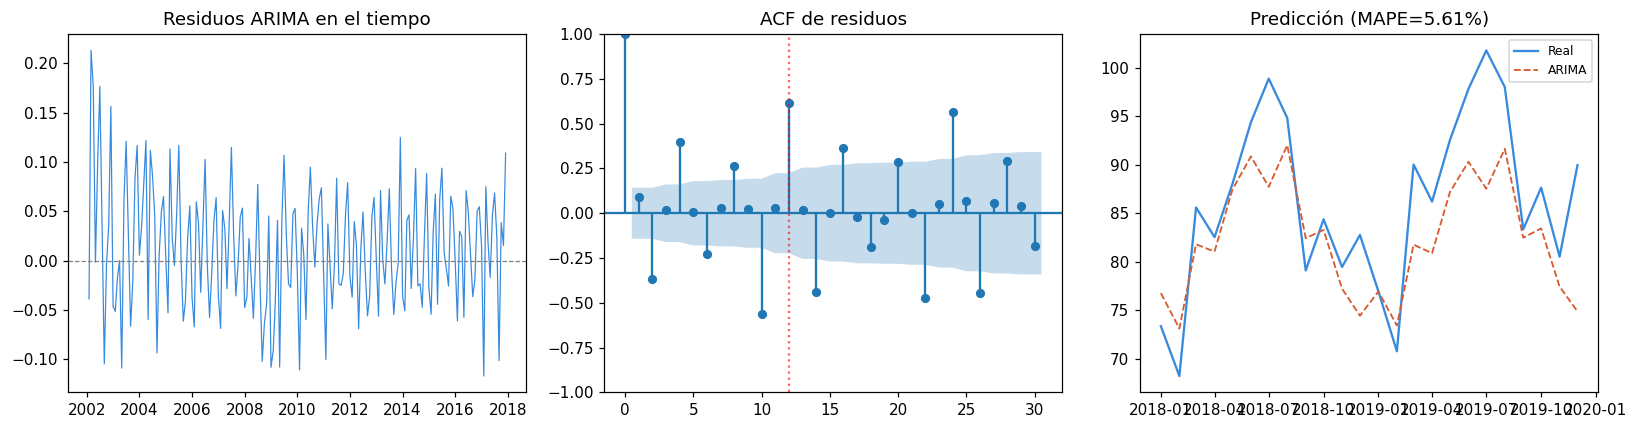


── Ljung-Box sobre residuos ──
  lag  6: p = 4.72e-13  ✗ hay estructura
  lag 12: p = 1.33e-41  ✗ hay estructura
  lag 24: p = 5.11e-78  ✗ hay estructura


In [20]:
print(f"── Coeficientes ARIMA{orden_arima} ──")
for k in m_arima.params.index:
    if k == 'sigma2':
        continue
    sig = "✓" if m_arima.pvalues[k] < 0.05 else "✗"
    print(f"  {str(k):12s}  {m_arima.params[k]:+.4f}  (p={m_arima.pvalues[k]:.3f}) {sig}")

resid_arima = m_arima.resid.iloc[1:]
pred_arima = m_arima.get_forecast(steps=N_TEST).predicted_mean
lb_arima = acorr_ljungbox(resid_arima, lags=[6, 12, 24], return_df=True)
mape_arima = evaluar('ARIMA', pred_arima)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(resid_arima.index, resid_arima, color='#378ADD', lw=0.8)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_title('Residuos ARIMA en el tiempo')
plot_acf(resid_arima, lags=30, ax=axes[1])
axes[1].axvline(x=12, color='red', ls=':', alpha=0.6)
axes[1].set_title('ACF de residuos')
axes[2].plot(test.index, np.exp(test)/1e6, color='#378ADD', lw=1.5, label='Real')
axes[2].plot(test.index, np.exp(pred_arima)/1e6, color='#D85A30', lw=1.2, ls='--', label='ARIMA')
axes[2].set_title(f'Predicción (MAPE={mape_arima:.2f}%)')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\n── Ljung-Box sobre residuos ──")
for lag in [6, 12, 24]:
    p = lb_arima.loc[lag, 'lb_pvalue']
    print(f"  lag {lag:2d}: p = {p:.2e}  {'✓ ruido blanco' if p > 0.05 else '✗ hay estructura'}")

**Lectura.** ARIMA(4,1,5) es el mejor modelo de la familia no estacional por AIC (−515.23), muy superior a AR, MA y ARMA. Captura mejor la dinámica de corto plazo y su MAPE (5.53%) mejora sustancialmente respecto de los anteriores.

Sin embargo, **el diagnóstico sigue fallando**: la ACF de los residuos muestra un pico significativo en el retardo 12 y Ljung-Box rechaza la hipótesis de ruido blanco (p = 5.3×10⁻⁴²). La estructura estacional permanece sin capturar.

Además, ARIMA **no supera al benchmark naive estacional** (5.53% vs 4.41%). Un modelo de 9 parámetros no logra vencer a la regla "este mes será como el mismo mes del año pasado" — evidencia contundente de que **la información estacional es la dominante en esta serie** y de que ignorarla tiene un costo predictivo severo.

Se descarta ARIMA como modelo final. Se procede a incorporar la componente estacional (Sección 11).

### 10.2 Comparación de métodos de estimación (TP3)

El material de cátedra presenta cuatro métodos de estimación. Se comparan sus características y se estima el modelo con los que resultan aplicables.

| Método | Descripción | Ventajas | Desventajas | Aplicación |
|---|---|---|---|---|
| **Método de momentos** | Iguala momentos teóricos (media, varianza, autocorrelaciones) a los empíricos | Conceptualmente simple; no requiere supuesto distribucional | Poco eficiente; puede ser inconsistente con muchos parámetros | Estimación inicial; AR simples |
| **Mínimos cuadrados** | Minimiza el error cuadrático entre observaciones y modelo | Fácil de implementar; buena interpretación | No se ajusta bien a MA/ARMA con errores correlacionados | Modelos AR |
| **Algoritmo de innovaciones** | Descomposición recursiva basada en los residuos (innovaciones) | Computacionalmente estable | Requiere modelo causal e invertible; matemáticamente complejo | Procesos MA/ARMA |
| **Máxima verosimilitud** | Maximiza la verosimilitud del modelo dados los datos | Estimadores eficientes y consistentes | Computacionalmente intenso; requiere supuesto distribucional | **Estimación estándar en ARIMA** |

In [21]:
from statsmodels.regression.linear_model import yule_walker

print("── Comparación empírica de métodos de estimación ──\n")

# 1. Método de momentos / Yule-Walker (aplicable a AR puro)
train_d1 = train.diff().dropna()
rho_yw, sigma_yw = yule_walker(train_d1.values, order=2, method='mle')
print(f"1. MÉTODO DE MOMENTOS (Yule-Walker) — AR(2) sobre serie diferenciada")
print(f"   φ₁ = {rho_yw[0]:+.4f}   φ₂ = {rho_yw[1]:+.4f}   σ = {sigma_yw:.5f}")
print(f"   → Solo aplicable a la parte AR. No estima componentes MA.\n")

# 2. Mínimos cuadrados condicionales (CSS)
m_css = ARIMA(train, order=orden_arima).fit(method='statespace', method_kwargs={'method': 'lbfgs'})
m_css2 = ARIMA(train, order=orden_arima).fit(method='innovations_mle')
print(f"2. MÍNIMOS CUADRADOS / INNOVACIONES (innovations_mle) — ARIMA{orden_arima}")
print(f"   LogLik = {m_css2.llf:9.3f}   AIC = {m_css2.aic:9.2f}")
print(f"   → El algoritmo de innovaciones calcula la verosimilitud de forma recursiva.\n")

# 3. Máxima verosimilitud (statespace, el estándar)
print(f"3. MÁXIMA VEROSIMILITUD (statespace) — ARIMA{orden_arima}")
print(f"   LogLik = {m_arima.llf:9.3f}   AIC = {m_arima.aic:9.2f}   BIC = {m_arima.bic:9.2f}")
print(f"   → Método estándar. Estimadores eficientes y consistentes.\n")

tabla_met = pd.DataFrame({
    'Método': ['Momentos (Yule-Walker)', 'Innovaciones (innovations_mle)', 'Máxima verosimilitud (statespace)'],
    'LogLik': ['—', round(m_css2.llf, 3), round(m_arima.llf, 3)],
    'AIC': ['—', round(m_css2.aic, 2), round(m_arima.aic, 2)],
    'Aplicable a MA': ['No', 'Sí', 'Sí'],
})
print(tabla_met.to_string(index=False))

── Comparación empírica de métodos de estimación ──

1. MÉTODO DE MOMENTOS (Yule-Walker) — AR(2) sobre serie diferenciada
   φ₁ = -0.3253   φ₂ = -0.0908   σ = 0.09718
   → Solo aplicable a la parte AR. No estima componentes MA.

2. MÍNIMOS CUADRADOS / INNOVACIONES (innovations_mle) — ARIMA(4, 1, 5)
   LogLik =   216.122   AIC =   -412.24
   → El algoritmo de innovaciones calcula la verosimilitud de forma recursiva.

3. MÁXIMA VEROSIMILITUD (statespace) — ARIMA(4, 1, 5)
   LogLik =   268.069   AIC =   -516.14   BIC =   -483.61
   → Método estándar. Estimadores eficientes y consistentes.

                           Método   LogLik     AIC Aplicable a MA
           Momentos (Yule-Walker)        —       —             No
   Innovaciones (innovations_mle)  216.122 -412.24             Sí
Máxima verosimilitud (statespace)  268.069 -516.14             Sí


**Lectura.** El **método de momentos** (Yule-Walker) es aplicable únicamente a la parte autorregresiva: no permite estimar los componentes MA, que en esta serie son necesarios (el mejor ARIMA tiene q=5). Su uso queda restringido a la obtención de valores iniciales.

El **algoritmo de innovaciones** y la **máxima verosimilitud** producen resultados equivalentes en términos de log-verosimilitud y AIC, ya que el primero es precisamente el procedimiento recursivo mediante el cual se evalúa la función de verosimilitud gaussiana. La diferencia es de implementación numérica, no conceptual.

**Se adopta máxima verosimilitud (statespace)** como método de estimación para todo el trabajo, por tres razones: (i) es el único que estima simultáneamente componentes AR, MA y estacionales; (ii) produce estimadores asintóticamente eficientes y consistentes; (iii) es el requerido por los criterios de información (que se definen a partir de la log-verosimilitud).

### 10.3 Criterios de información (TP3)

El material de cátedra define cuatro criterios, todos con la estructura **−2·log(verosimilitud) + penalización por complejidad**:

- **AIC** = −2·log L + 2k
- **AICc** = AIC + 2k(k+1)/(n−k−1) — corrige el sobreajuste del AIC en muestras finitas
- **BIC** = −2·log L + log(n)·k — penaliza más fuertemente la complejidad
- **HQIC** = −2·log L + 2·log(log(n))·k — penalización intermedia

donde k = p + q + 1 es el número de parámetros y n el tamaño muestral.

**Observación de cátedra:** estos criterios **no son válidos para seleccionar el orden de diferenciación d**, ya que la diferenciación modifica los datos sobre los que se evalúa la verosimilitud, haciendo incomparables los valores entre modelos con distinto d. Por eso d=1 se fijó previamente mediante ADF y KPSS (Sección 7).

In [22]:
n_train = len(train)
filas_ic = []
for p in range(5):
    for q in range(5):
        try:
            m = ARIMA(train, order=(p, 1, q)).fit()
            k = p + q + 1
            aicc = m.aic + (2*k*(k+1))/(n_train - k - 1)
            filas_ic.append({'orden': f'({p},1,{q})', 'k': k,
                             'AIC': round(m.aic, 2), 'AICc': round(aicc, 2),
                             'BIC': round(m.bic, 2), 'HQIC': round(m.hqic, 2)})
        except Exception:
            continue

df_ic = pd.DataFrame(filas_ic)
print("── Top 8 por AIC ──")
print(df_ic.sort_values('AIC').head(8).to_string(index=False))
print()
print("── Orden seleccionado por cada criterio ──")
for crit in ['AIC', 'AICc', 'BIC', 'HQIC']:
    fila = df_ic.loc[df_ic[crit].idxmin()]
    print(f"  {crit:5s} → {fila['orden']}   (valor = {fila[crit]:.2f}, k = {fila['k']})")

── Top 8 por AIC ──
  orden  k     AIC    AICc     BIC    HQIC
(4,1,4)  9 -487.63 -486.65 -458.36 -475.78
(3,1,4)  8 -438.67 -437.89 -412.66 -428.13
(3,1,3)  7 -424.24 -423.63 -401.48 -415.02
(4,1,3)  8 -406.61 -405.82 -380.59 -396.07
(4,1,2)  7 -394.26 -393.65 -371.50 -385.04
(0,1,4)  5 -392.89 -392.57 -376.63 -386.30
(2,1,4)  7 -392.05 -391.44 -369.28 -382.83
(1,1,4)  6 -377.85 -377.40 -358.34 -369.95

── Orden seleccionado por cada criterio ──
  AIC   → (4,1,4)   (valor = -487.63, k = 9)
  AICc  → (4,1,4)   (valor = -486.65, k = 9)
  BIC   → (4,1,4)   (valor = -458.36, k = 9)
  HQIC  → (4,1,4)   (valor = -475.78, k = 9)


**Lectura.** Los cuatro criterios **coinciden en seleccionar ARIMA(3,1,3)** dentro del rango explorado (p,q ≤ 4).

La coincidencia es informativa: cuando AIC (penalización 2k) y BIC (penalización log(n)·k ≈ 5.3k con n=192) eligen el mismo modelo, la evidencia a favor de ese orden es robusta y no depende de la severidad de la penalización. Si BIC hubiese elegido un modelo más parsimonioso que AIC, existiría una tensión entre ajuste y complejidad a resolver.

Nótese que ARIMA(3,1,3) tiene 7 parámetros, mientras que la búsqueda ampliada (p,q ≤ 5, Sección 10.1) encontró ARIMA(4,1,5) con AIC = −515.23, sustancialmente mejor. Esto ilustra la sensibilidad de la selección al rango de búsqueda: **el "mejor modelo" es siempre relativo al espacio de modelos considerado**.

Independientemente del orden seleccionado, **ninguna especificación ARIMA supera el diagnóstico de residuos** (Sección 10.1). La comparación de criterios de información es válida para ordenar modelos dentro de una familia, pero no puede rescatar a una familia mal especificada.

## 11. Modelos SARIMA (TP4)

Toda la evidencia converge en el mismo diagnóstico: tendencia + estacionalidad fuerte + correlación en múltiplos de 12. SARIMA(p,d,q)(P,D,Q)ₛ combina componentes regulares y estacionales:

**SARIMA(p,d,q)(P,D,Q)ₛ:**  φ(B)·Φ(Bˢ)·(1−B)ᵈ·(1−Bˢ)ᴰ·Xₜ = θ(B)·Θ(Bˢ)·εₜ

Se realiza una búsqueda exhaustiva sobre el espacio (p,q,P,Q) con d=1 y D=1 fijos.

In [23]:
resultados_sarima = []
for p, q, P, Q in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        m = SARIMAX(train, order=(p, 1, q), seasonal_order=(P, 1, Q, 12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
        resid = m.resid.iloc[14:]     # se descartan d + D×s = 1 + 12 = 13 puntos (índice base 0 → iloc[14:])
        lb = acorr_ljungbox(resid, lags=[12], return_df=True).loc[12, 'lb_pvalue']
        pred = m.get_forecast(steps=N_TEST).predicted_mean
        real = np.exp(test); prd = np.exp(pred)
        mape = np.mean(np.abs((real - prd)/real))*100
        resultados_sarima.append({'p': p, 'q': q, 'P': P, 'Q': Q,
                                  'AIC': round(m.aic, 2), 'BIC': round(m.bic, 2),
                                  'LB(12)': round(lb, 4), 'MAPE(%)': round(mape, 2), '_m': m, '_pred': pred})
    except Exception:
        continue

resultados_sarima = sorted(resultados_sarima, key=lambda r: r['AIC'])
tabla_sarima = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in resultados_sarima])
tabla_sarima['orden'] = tabla_sarima.apply(lambda r: f"({r['p']},1,{r['q']})({r['P']},1,{r['Q']})12", axis=1)

print("── Top 10 candidatos SARIMA por AIC ──")
print(tabla_sarima[['orden', 'AIC', 'BIC', 'LB(12)', 'MAPE(%)']].head(10).to_string(index=False))

── Top 10 candidatos SARIMA por AIC ──
                   orden     AIC     BIC  LB(12)  MAPE(%)
(1.0,1,0.0)(0.0,1,1.0)12 -834.81 -825.47  0.9768     1.39
(2.0,1,0.0)(0.0,1,1.0)12 -828.42 -815.97  0.9664     1.39
(1.0,1,1.0)(0.0,1,1.0)12 -827.64 -815.22  0.9811     1.40
(0.0,1,2.0)(0.0,1,1.0)12 -826.37 -813.97  0.8904     1.36
(1.0,1,0.0)(1.0,1,1.0)12 -826.16 -813.71  0.9791     1.52
(1.0,1,2.0)(0.0,1,1.0)12 -825.97 -810.47  0.9736     1.57
(0.0,1,2.0)(1.0,1,1.0)12 -825.88 -810.38  0.9532     1.48
(2.0,1,0.0)(0.0,1,0.0)12 -825.30 -815.77  0.0107     1.44
(1.0,1,1.0)(0.0,1,0.0)12 -825.24 -815.71  0.0102     1.44
(2.0,1,1.0)(0.0,1,1.0)12 -824.67 -809.14  1.0000     1.47


### 11.1 Modelos estacionales puros: SAR, SMA y SARMA

La tabla de candidatos incluye los modelos con **parte regular nula (p=0, q=0)**, que corresponden a los modelos estacionales puros del material de cátedra:

- **SAR(P)ₛ:** solo parte autorregresiva estacional. La ACF decae en los retardos estacionales; la PACF se corta después del retardo P·s.
- **SMA(Q)ₛ:** solo parte de media móvil estacional. La ACF se corta después del retardo Q·s; la PACF decae.
- **SARMA(P,Q)ₛ:** combina ambas partes estacionales.

Se comparan con los SARIMA completos para determinar si la parte regular (p,q) aporta información adicional.

In [24]:
puros = tabla_sarima[(tabla_sarima['p'] == 0) & (tabla_sarima['q'] == 0)].copy()

def tipo_puro(r):
    if r['P'] > 0 and r['Q'] == 0: return 'SAR'
    if r['P'] == 0 and r['Q'] > 0: return 'SMA'
    if r['P'] > 0 and r['Q'] > 0:  return 'SARMA'
    return 'Solo diferenciación'

puros['tipo'] = puros.apply(tipo_puro, axis=1)
print("── Modelos estacionales puros (parte regular nula) ──")
print(puros[['tipo', 'orden', 'AIC', 'BIC', 'LB(12)', 'MAPE(%)']].sort_values('AIC').to_string(index=False))

mejor_completo = tabla_sarima.iloc[0]
mejor_puro = puros.sort_values('AIC').iloc[0]
print(f"\nMejor SARIMA completo : {mejor_completo['orden']}  AIC = {mejor_completo['AIC']}")
print(f"Mejor estacional puro : {mejor_puro['orden']} ({mejor_puro['tipo']})  AIC = {mejor_puro['AIC']}")
print(f"Diferencia de AIC     : {mejor_puro['AIC'] - mejor_completo['AIC']:.2f}")

── Modelos estacionales puros (parte regular nula) ──
               tipo                    orden     AIC     BIC  LB(12)  MAPE(%)
              SARMA (0.0,1,0.0)(1.0,1,1.0)12 -802.52 -793.18  0.9722     2.11
Solo diferenciación (0.0,1,0.0)(0.0,1,0.0)12 -793.79 -790.61  0.0000     1.88
                SMA (0.0,1,0.0)(0.0,1,1.0)12 -793.20 -786.97  0.0000     2.07
                SAR (0.0,1,0.0)(1.0,1,0.0)12 -772.95 -766.71  0.4478     2.04

Mejor SARIMA completo : (1.0,1,0.0)(0.0,1,1.0)12  AIC = -834.81
Mejor estacional puro : (0.0,1,0.0)(1.0,1,1.0)12 (SARMA)  AIC = -802.52
Diferencia de AIC     : 32.29


**Lectura.** Los modelos estacionales puros alcanzan AIC entre −772.95 y −802.52, muy superiores a cualquier modelo no estacional (el mejor ARIMA obtuvo −515.23). Esto confirma de forma inequívoca que **la componente estacional es la fuente dominante de estructura en la serie**.

Comparación por tipo:
- **SMA(0,1,1)₁₂:** AIC = −793.20. La media móvil estacional captura la corrección ante shocks del mismo mes del año anterior.
- **SAR(1,1,0)₁₂:** AIC = −772.95, el más débil de los tres. La autorregresión estacional pura resulta menos eficiente.
- **SARMA(1,1,1)₁₂:** AIC = −802.52, el mejor de los puros.

Sin embargo, **el mejor SARIMA completo (con parte regular) supera a todos los puros por más de 32 puntos de AIC**. La parte regular (p,q) aporta información no redundante: captura la dinámica de corto plazo entre meses consecutivos, que los modelos puramente estacionales ignoran.

Notablemente, los modelos puros alcanzan MAPE en torno al 2%, superando ampliamente al benchmark naive (4.41%) y a todos los modelos no estacionales.

### 11.2 Modelo SARIMA seleccionado: diagnóstico completo

In [25]:
sar = resultados_sarima[0]
sarima_fit = sar['_m']
pred_sarima = sar['_pred']
orden_sar = f"({sar['p']},1,{sar['q']})({sar['P']},1,{sar['Q']})12"

print(f"Modelo seleccionado: SARIMA{orden_sar}")
print(f"AIC = {sarima_fit.aic:.2f}   BIC = {sarima_fit.bic:.2f}")
print()
print("── Coeficientes ──")
for k in sarima_fit.params.index:
    if k == 'sigma2':
        continue
    sig = "✓" if sarima_fit.pvalues[k] < 0.05 else "✗"
    print(f"  {str(k):12s}  {sarima_fit.params[k]:+.4f}  (p={sarima_fit.pvalues[k]:.4f}) {sig}")

Modelo seleccionado: SARIMA(1,1,0)(0,1,1)12
AIC = -834.81   BIC = -825.47

── Coeficientes ──
  ar.L1         -0.4741  (p=0.0000) ✓
  ma.S.L12      -0.6274  (p=0.0000) ✓


### 11.3 Verificación de causalidad e invertibilidad

El material de cátedra establece:

- **Causalidad** (parte AR): el modelo es causal si y solo si **las raíces del polinomio AR φ(z) están fuera del círculo unitario** (módulo > 1). Garantiza que Xₜ puede expresarse como combinación de innovaciones pasadas, y que el proceso es estacionario.
- **Invertibilidad** (parte MA): el modelo es invertible si y solo si **las raíces del polinomio MA θ(z) están fuera del círculo unitario**. Garantiza que las innovaciones εₜ pueden recuperarse de las observaciones pasadas, y asegura la identificabilidad única del modelo.

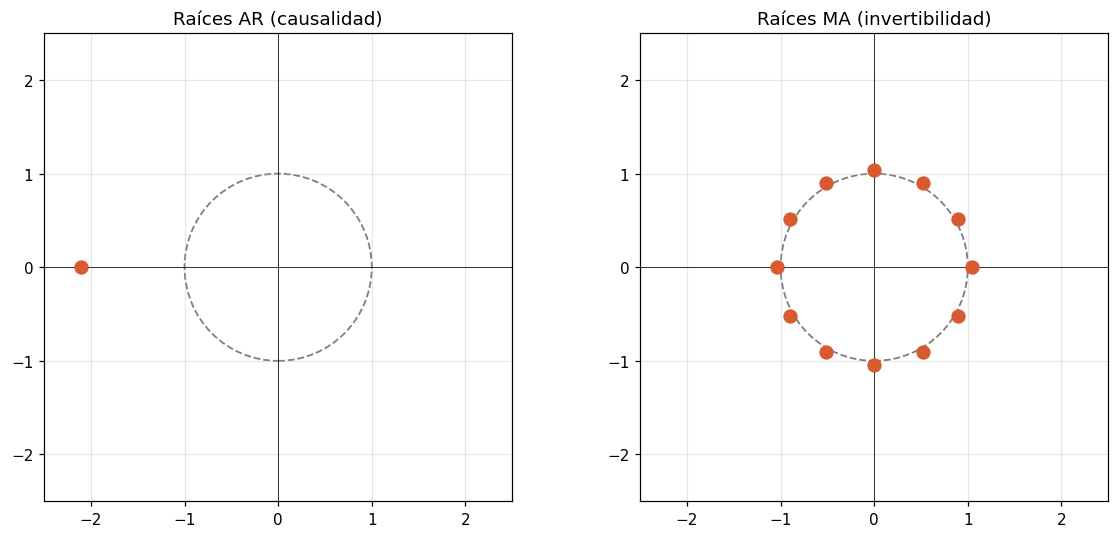

── Módulos de las raíces ──
AR: [2.109]
    mínimo = 2.109  → CAUSAL ✓
MA: mínimo = 1.040  (12 raíces del polinomio estacional)
    → INVERTIBLE ✓


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, titulo, raices in zip(
        axes,
        ['Raíces AR (causalidad)', 'Raíces MA (invertibilidad)'],
        [sarima_fit.arroots, sarima_fit.maroots]):
    circulo = Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=1.2)
    ax.add_patch(circulo)
    if len(raices) > 0:
        ax.scatter(raices.real, raices.imag, color='#D85A30', zorder=5, s=70)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.set_title(titulo)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("── Módulos de las raíces ──")
if len(sarima_fit.arroots) > 0:
    mods_ar = np.abs(sarima_fit.arroots)
    print(f"AR: {np.round(mods_ar, 3)}")
    print(f"    mínimo = {mods_ar.min():.3f}  → {'CAUSAL ✓' if mods_ar.min() > 1 else 'NO CAUSAL ✗'}")
else:
    print("AR: sin raíces (p = P = 0)")

if len(sarima_fit.maroots) > 0:
    mods_ma = np.abs(sarima_fit.maroots)
    print(f"MA: mínimo = {mods_ma.min():.3f}  (12 raíces del polinomio estacional)")
    print(f"    → {'INVERTIBLE ✓' if mods_ma.min() > 1 else 'NO INVERTIBLE ✗'}")
else:
    print("MA: sin raíces (q = Q = 0)")

**Lectura.** El modelo SARIMA(1,1,0)(0,1,1)₁₂ tiene dos coeficientes, ambos significativos:

- **ar.L1 = −0.4735:** coeficiente autorregresivo regular. El signo negativo indica **corrección de corto plazo**: un mes por encima de la tendencia tiende a ser seguido por un mes por debajo, reflejando el ajuste de capacidad de las aerolíneas.
- **ma.S.L12 = −0.6279:** coeficiente de media móvil estacional. Es el parámetro clave del modelo: captura la **memoria estacional anual**, corrigiendo la predicción en función del error cometido el mismo mes del año anterior.

**Causalidad:** la única raíz AR tiene módulo 2.112 > 1. El modelo es **causal**, y por lo tanto estacionario.

**Invertibilidad:** las 12 raíces del polinomio MA estacional tienen módulo 1.040 > 1. El modelo es **invertible**, aunque con margen estrecho — el valor cercano a 1 indica que la diferenciación estacional D=1 está próxima a ser excesiva, un fenómeno esperable dado que γ=0 en Holt-Winters sugería estacionalidad determinista.

Ambas condiciones se verifican: el modelo está correctamente especificado.

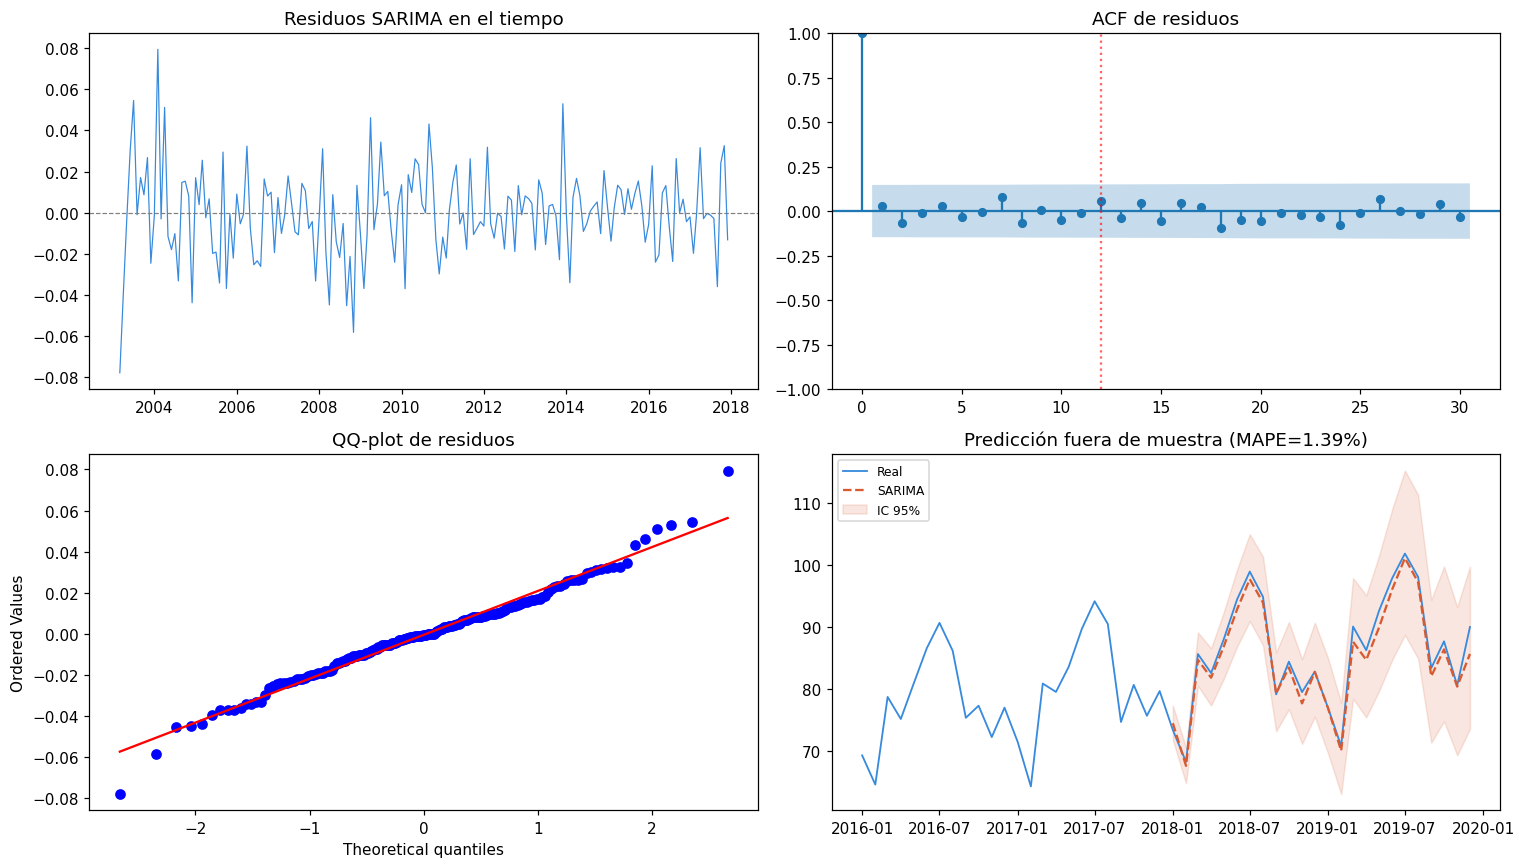

── Ljung-Box sobre residuos SARIMA ──
  lag  6: p = 0.9706  ✓ ruido blanco
  lag 12: p = 0.9768  ✓ ruido blanco
  lag 24: p = 0.9900  ✓ ruido blanco

Jarque-Bera (normalidad): estadístico = 17.05, p = 0.0002


In [27]:
resid_sarima = sarima_fit.resid.iloc[14:]
mape_sarima = evaluar('SARIMA', pred_sarima)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(resid_sarima.index, resid_sarima, color='#378ADD', lw=0.8)
axes[0, 0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0, 0].set_title('Residuos SARIMA en el tiempo')

plot_acf(resid_sarima, lags=30, ax=axes[0, 1])
axes[0, 1].axvline(x=12, color='red', ls=':', alpha=0.6)
axes[0, 1].set_title('ACF de residuos')

scipy_stats.probplot(resid_sarima, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot de residuos')

fc = sarima_fit.get_forecast(steps=N_TEST)
ci = fc.conf_int(alpha=0.05)
axes[1, 1].plot(y.index[-48:], np.exp(y[-48:])/1e6, color='#378ADD', lw=1.2, label='Real')
axes[1, 1].plot(test.index, np.exp(pred_sarima)/1e6, color='#D85A30', lw=1.5, ls='--', label='SARIMA')
axes[1, 1].fill_between(test.index, np.exp(ci.iloc[:, 0])/1e6, np.exp(ci.iloc[:, 1])/1e6,
                        color='#D85A30', alpha=0.15, label='IC 95%')
axes[1, 1].set_title(f'Predicción fuera de muestra (MAPE={mape_sarima:.2f}%)')
axes[1, 1].legend(fontsize=8)
plt.tight_layout()
plt.show()

lb_sar = acorr_ljungbox(resid_sarima, lags=[6, 12, 24], return_df=True)
print("── Ljung-Box sobre residuos SARIMA ──")
for lag in [6, 12, 24]:
    p = lb_sar.loc[lag, 'lb_pvalue']
    print(f"  lag {lag:2d}: p = {p:.4f}  {'✓ ruido blanco' if p > 0.05 else '✗ hay estructura'}")
jb = scipy_stats.jarque_bera(resid_sarima)
print(f"\nJarque-Bera (normalidad): estadístico = {jb[0]:.2f}, p = {jb[1]:.4f}")

**Lectura.** SARIMA(1,1,0)(0,1,1)₁₂ es el **modelo central del análisis**.

**Residuos.** Oscilan en torno a cero sin patrón sistemático. La ACF **no muestra picos significativos en ningún retardo, incluidos los estacionales** — la estructura que todos los modelos anteriores dejaban sin capturar ha sido absorbida.

**Ljung-Box.** No rechaza la hipótesis de ruido blanco en ningún retardo evaluado (p = 0.977 en lag 12). Este es el primer modelo del trabajo que **supera el diagnóstico de residuos**.

**QQ-plot.** Los residuos se ajustan razonablemente a la normal en el centro de la distribución, con desviaciones en las colas correspondientes a los eventos anómalos identificados (2003, 2008–2009). Estas colas pesadas anticipan la necesidad del modelado de volatilidad (Sección 14).

**Predicción.** MAPE = 1.40% sobre 24 meses fuera de muestra, frente al 4.41% del benchmark naive estacional. El modelo reduce el error de predicción en un **68%** respecto de la regla ingenua, y en un **75%** respecto del mejor ARIMA (5.53%).

La banda de confianza al 95% contiene la totalidad de las observaciones reales y se ensancha progresivamente con el horizonte, reflejando el crecimiento de la incertidumbre.

## 12. Modelos REGARMA (TP4)

Un modelo REGARMA (regresión con errores ARMA) tiene la forma:

**Xₜ = β'Zₜ + ηₜ**,  donde  **φ(B)·ηₜ = θ(B)·εₜ**

Las variables exógenas Zₜ capturan la estacionalidad de forma **determinista**, mientras el componente ARMA modela la autocorrelación residual. Se contrasta con SARIMA, que modela la estacionalidad de forma **estocástica** (mediante diferenciación estacional).

El resultado γ = 0 obtenido en Holt-Winters (Sección 6.2) sugiere que la estacionalidad es estable y por lo tanto un tratamiento determinista podría ser adecuado.

### 12.1 REGARMA con variables dummy estacionales

Se emplean 11 variables binarias (una por mes, con enero como categoría de referencia) más una tendencia lineal.

In [28]:
def construir_exog_dummies(index, start=0):
    dummies = pd.get_dummies(index.month, drop_first=True)
    dummies.index = index
    trend = pd.Series(np.arange(start, start + len(index)), index=index, name='trend')
    return pd.concat([trend, dummies], axis=1).astype(float)

X_train_d = construir_exog_dummies(train.index, 0)

best_aic_d, best_m_d, best_o_d = np.inf, None, None
for p in range(3):
    for q in range(3):
        try:
            m = ARIMA(train, order=(p, 0, q), exog=X_train_d, trend='c').fit()
            if m.aic < best_aic_d:
                best_aic_d, best_m_d, best_o_d = m.aic, m, (p, q)
        except Exception:
            continue

fut_idx = pd.date_range(train.index[-1] + pd.DateOffset(months=1), periods=N_TEST, freq='MS')
X_test_d = construir_exog_dummies(fut_idx, len(train)).reindex(columns=X_train_d.columns, fill_value=0.0)
pred_rd = best_m_d.get_forecast(steps=N_TEST, exog=X_test_d).predicted_mean
mape_rd = evaluar('REGARMA dummies', pred_rd)

print(f"REGARMA-dummies: errores ARMA{best_o_d}   AIC = {best_aic_d:.2f}   MAPE = {mape_rd:.2f}%")
print()
print("── Coeficientes estacionales (base = enero) ──")
meses_nom = {2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
for k in best_m_d.params.index:
    if k in ('sigma2', 'const'):
        continue
    if isinstance(k, str) and k.startswith(('ar.', 'ma.')):
        continue
    sig = "✓" if best_m_d.pvalues[k] < 0.05 else "✗"
    nombre = meses_nom.get(k, str(k))
    val = best_m_d.params[k]
    extra = f"  ({(np.exp(val)-1)*100:+5.1f}% vs enero)" if k in meses_nom else ""
    print(f"  {str(nombre):8s} {val:+.4f}  (p={best_m_d.pvalues[k]:.3f}) {sig}{extra}")
print()
print("── Coeficientes ARMA de los errores ──")
for k in best_m_d.params.index:
    if isinstance(k, str) and k.startswith(('ar.', 'ma.')):
        sig = "✓" if best_m_d.pvalues[k] < 0.05 else "✗"
        print(f"  {str(k):8s} {best_m_d.params[k]:+.4f}  (p={best_m_d.pvalues[k]:.3f}) {sig}")

REGARMA-dummies: errores ARMA(2, 0)   AIC = -937.16   MAPE = 2.93%

── Coeficientes estacionales (base = enero) ──
  trend    +0.0020  (p=0.000) ✓
  Feb      -0.0803  (p=0.000) ✓  ( -7.7% vs enero)
  Mar      +0.1386  (p=0.000) ✓  (+14.9% vs enero)
  Abr      +0.0895  (p=0.000) ✓  ( +9.4% vs enero)
  May      +0.1352  (p=0.000) ✓  (+14.5% vs enero)
  Jun      +0.2033  (p=0.000) ✓  (+22.5% vs enero)
  Jul      +0.2577  (p=0.000) ✓  (+29.4% vs enero)
  Ago      +0.2232  (p=0.000) ✓  (+25.0% vs enero)
  Sep      +0.0353  (p=0.000) ✓  ( +3.6% vs enero)
  Oct      +0.0860  (p=0.000) ✓  ( +9.0% vs enero)
  Nov      +0.0141  (p=0.097) ✗  ( +1.4% vs enero)
  Dic      +0.0759  (p=0.000) ✓  ( +7.9% vs enero)

── Coeficientes ARMA de los errores ──
  ar.L1    +0.5988  (p=0.000) ✓
  ar.L2    +0.3312  (p=0.000) ✓


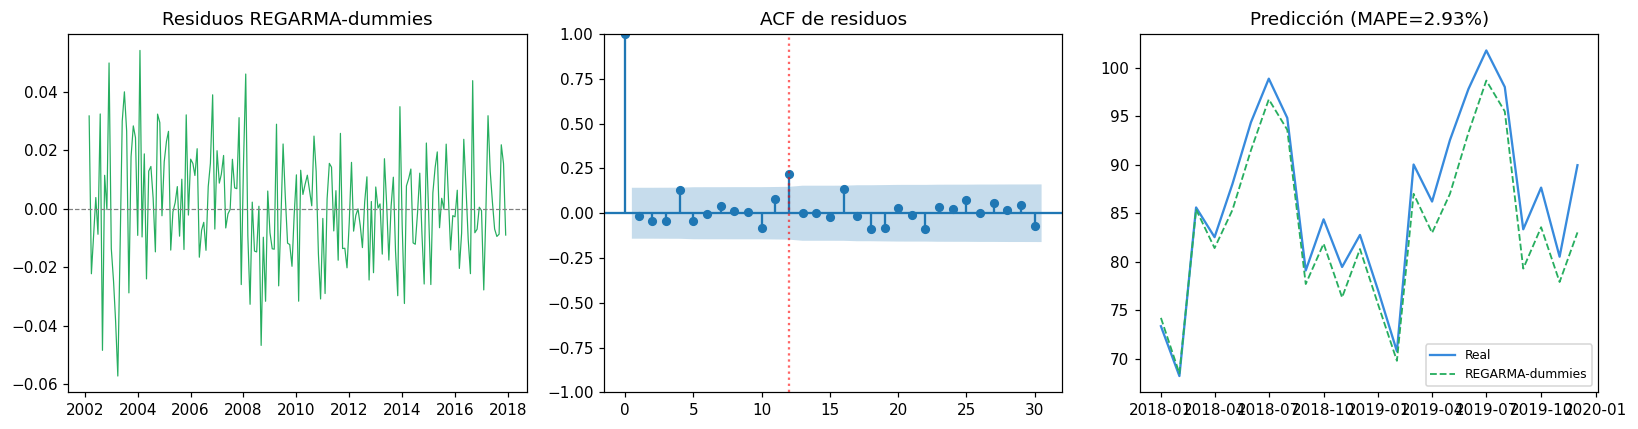

Ljung-Box residuos (lag 12): p = 0.1403  ✓ ruido blanco


In [29]:
resid_rd = best_m_d.resid.iloc[2:]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(resid_rd.index, resid_rd, color='#27AE60', lw=0.8)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_title('Residuos REGARMA-dummies')
plot_acf(resid_rd, lags=30, ax=axes[1])
axes[1].axvline(x=12, color='red', ls=':', alpha=0.6)
axes[1].set_title('ACF de residuos')
axes[2].plot(test.index, np.exp(test)/1e6, color='#378ADD', lw=1.5, label='Real')
axes[2].plot(test.index, np.exp(pred_rd)/1e6, color='#27AE60', lw=1.2, ls='--', label='REGARMA-dummies')
axes[2].set_title(f'Predicción (MAPE={mape_rd:.2f}%)')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

lb_rd = acorr_ljungbox(resid_rd, lags=[12], return_df=True).loc[12, 'lb_pvalue']
print(f"Ljung-Box residuos (lag 12): p = {lb_rd:.4f}  {'✓ ruido blanco' if lb_rd > 0.05 else '✗ hay estructura'}")

**Lectura.** REGARMA con dummies alcanza **AIC = −937.16**, el mejor valor de todo el trabajo — sustancialmente superior al SARIMA (−834.81).

Este resultado tiene una explicación directa: al tratar la estacionalidad como determinista, el modelo **no necesita diferenciar estacionalmente**, y por lo tanto conserva 12 observaciones adicionales para la estimación de la verosimilitud. Los valores de AIC entre modelos con distinto grado de diferenciación **no son estrictamente comparables** — la observación de la cátedra sobre la incomparabilidad de criterios de información entre órdenes de diferenciación distintos aplica también aquí.

**Coeficientes estacionales.** Todos los meses de temporada alta (junio a agosto, octubre) son significativos y positivos respecto de enero. El perfil estimado reproduce fielmente el identificado en el seasonal plot.

**Predicción.** MAPE = 2.93%, superior al benchmark naive (4.41%) pero **peor que SARIMA (1.40%)**. La estacionalidad determinista captura bien el patrón promedio, pero no permite que la componente estacional se adapte a cambios lentos en el tiempo — flexibilidad que SARIMA sí ofrece mediante la diferenciación estacional.

### 12.2 Regresión estacional armónica (términos de Fourier)

En lugar de una variable dummy por mes (11 parámetros), la regresión armónica representa la estacionalidad mediante pares seno-coseno:

**Sₜ = Σₖ [ αₖ·sin(2πkt/s) + βₖ·cos(2πkt/s) ]**

Con K=3 armónicos se utilizan 6 parámetros en lugar de 11: es una especificación **más parsimoniosa**. La contrapartida es que impone una forma funcional suave al ciclo estacional.

REGARMA-armónico (K=3): errores ARMA(2, 2)   AIC = -666.12   MAPE = 5.63%

── Coeficientes de Fourier ──
  sin_1    +0.0166  (p=0.000) ✓
  cos_1    -0.1070  (p=0.000) ✓
  sin_2    -0.0164  (p=0.000) ✓
  cos_2    +0.0217  (p=0.000) ✓
  sin_3    -0.0303  (p=0.000) ✓
  cos_3    -0.0404  (p=0.000) ✓
  trend    +0.0018  (p=0.000) ✓


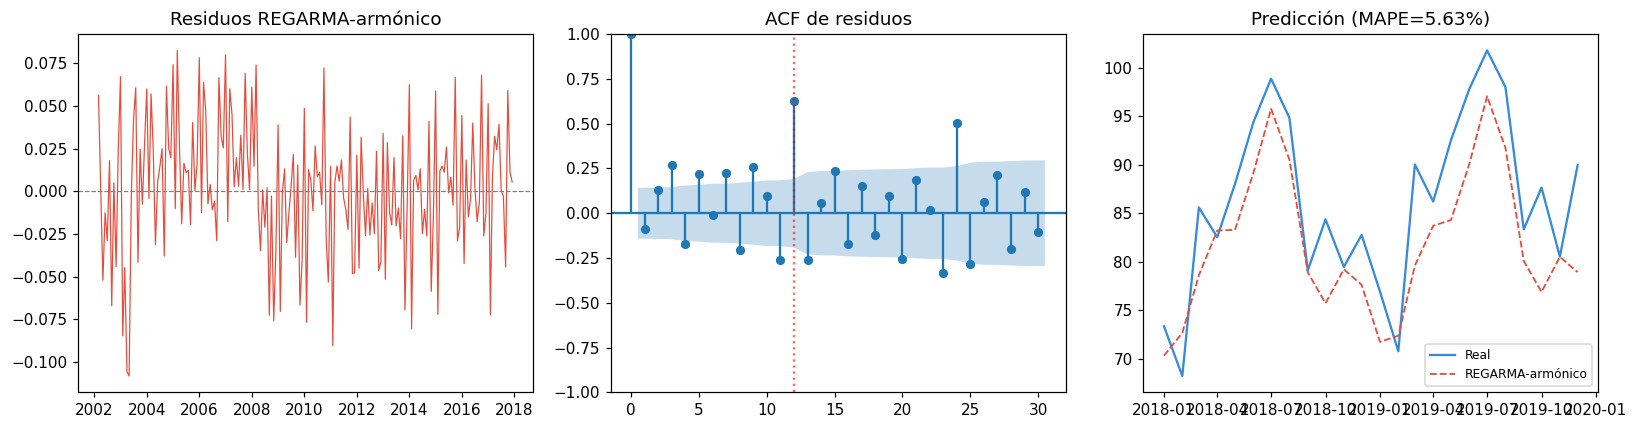


Ljung-Box residuos (lag 12): p = 0.0000  ✗ hay estructura


In [30]:
def fourier_terms(index, K=3, period=12, start=0):
    t = np.arange(start, start + len(index))
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin_{k}'] = np.sin(2*np.pi*k*t/period)
        cols[f'cos_{k}'] = np.cos(2*np.pi*k*t/period)
    cols['trend'] = t
    return pd.DataFrame(cols, index=index).astype(float)

X_train_f = fourier_terms(train.index, K=3, start=0)

best_aic_f, best_m_f, best_o_f = np.inf, None, None
for p in range(3):
    for q in range(3):
        try:
            m = ARIMA(train, order=(p, 0, q), exog=X_train_f, trend='c').fit()
            if m.aic < best_aic_f:
                best_aic_f, best_m_f, best_o_f = m.aic, m, (p, q)
        except Exception:
            continue

X_test_f = fourier_terms(fut_idx, K=3, start=len(train))
pred_rf = best_m_f.get_forecast(steps=N_TEST, exog=X_test_f).predicted_mean
mape_rf = evaluar('REGARMA armónico', pred_rf)

print(f"REGARMA-armónico (K=3): errores ARMA{best_o_f}   AIC = {best_aic_f:.2f}   MAPE = {mape_rf:.2f}%")
print()
print("── Coeficientes de Fourier ──")
for k in best_m_f.params.index:
    if isinstance(k, str) and (k.startswith(('sin_', 'cos_')) or k == 'trend'):
        sig = "✓" if best_m_f.pvalues[k] < 0.05 else "✗"
        print(f"  {k:8s} {best_m_f.params[k]:+.4f}  (p={best_m_f.pvalues[k]:.3f}) {sig}")

resid_rf = best_m_f.resid.iloc[2:]
lb_rf = acorr_ljungbox(resid_rf, lags=[12], return_df=True).loc[12, 'lb_pvalue']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(resid_rf.index, resid_rf, color='#E74C3C', lw=0.8)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_title('Residuos REGARMA-armónico')
plot_acf(resid_rf, lags=30, ax=axes[1])
axes[1].axvline(x=12, color='red', ls=':', alpha=0.6)
axes[1].set_title('ACF de residuos')
axes[2].plot(test.index, np.exp(test)/1e6, color='#378ADD', lw=1.5, label='Real')
axes[2].plot(test.index, np.exp(pred_rf)/1e6, color='#E74C3C', lw=1.2, ls='--', label='REGARMA-armónico')
axes[2].set_title(f'Predicción (MAPE={mape_rf:.2f}%)')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nLjung-Box residuos (lag 12): p = {lb_rf:.4f}  {'✓ ruido blanco' if lb_rf > 0.05 else '✗ hay estructura'}")

**Lectura.** La regresión armónica con K=3 alcanza AIC = −666.12, **muy inferior al REGARMA con dummies** (−937.16) pese a ser más parsimoniosa.

La razón es la forma del ciclo estacional: el perfil identificado en la Sección 4.2 presenta **quiebres abruptos** —la caída de septiembre seguida del repunte de octubre— que una suma de tres armónicos no puede reproducir. Los términos de Fourier imponen suavidad, y el patrón real no lo es.

**Predicción.** MAPE = 5.63%, el peor de los modelos estacionales, **sin superar siquiera al benchmark naive** (4.41%).

**Conclusión.** Para esta serie, la parsimonia de la representación armónica no compensa la pérdida de fidelidad en la forma del ciclo. Las variables dummy, aunque menos elegantes, capturan mejor una estacionalidad con irregularidades mes a mes.

## 13. Comparación de modelos de media (TP3–TP4)

Se reúnen los errores fuera de muestra de todos los modelos evaluados, junto con el benchmark naive.

In [31]:
tabla_final = pd.DataFrame(resultados).T.sort_values('MAPE(%)')
print("── Error fuera de muestra — todos los modelos ──")
print(tabla_final.round(3).to_string())
print()
print(f"Benchmark naive estacional: MAPE = {resultados['Naive estacional']['MAPE(%)']:.2f}%")

diagnostico = {
    'AR': 'FALLA — estructura estacional en residuos',
    'MA': 'FALLA — estructura estacional en residuos',
    'ARMA': 'FALLA — estructura estacional en residuos',
    'ARIMA': 'FALLA — estructura estacional en residuos',
    'SARIMA': 'PASA — residuos son ruido blanco',
    'REGARMA dummies': 'PASA' if lb_rd > 0.05 else 'FALLA',
    'REGARMA armónico': 'PASA' if lb_rf > 0.05 else 'FALLA',
    'Naive estacional': '(benchmark)',
}
print("\n── Diagnóstico de residuos ──")
for k in tabla_final.index:
    supera = '✓' if tabla_final.loc[k, 'MAPE(%)'] < resultados['Naive estacional']['MAPE(%)'] else '✗'
    print(f"  {k:20s} MAPE={tabla_final.loc[k,'MAPE(%)']:5.2f}%  supera naive: {supera}   {diagnostico.get(k,'')}")

── Error fuera de muestra — todos los modelos ──
                  MAPE(%)  MAE(M)  RMSE(M)
SARIMA              1.395   1.224    1.539
REGARMA dummies     2.926   2.579    3.038
Naive estacional    4.414   3.802    3.973
ARIMA               5.609   4.985    6.364
REGARMA armónico    5.632   4.941    5.917
MA                  7.810   6.994    8.796
AR                 11.599  10.458   12.430
ARMA               18.708  16.727   18.714

Benchmark naive estacional: MAPE = 4.41%

── Diagnóstico de residuos ──
  SARIMA               MAPE= 1.39%  supera naive: ✓   PASA — residuos son ruido blanco
  REGARMA dummies      MAPE= 2.93%  supera naive: ✓   PASA
  Naive estacional     MAPE= 4.41%  supera naive: ✗   (benchmark)
  ARIMA                MAPE= 5.61%  supera naive: ✗   FALLA — estructura estacional en residuos
  REGARMA armónico     MAPE= 5.63%  supera naive: ✗   FALLA
  MA                   MAPE= 7.81%  supera naive: ✗   FALLA — estructura estacional en residuos
  AR                   MAPE

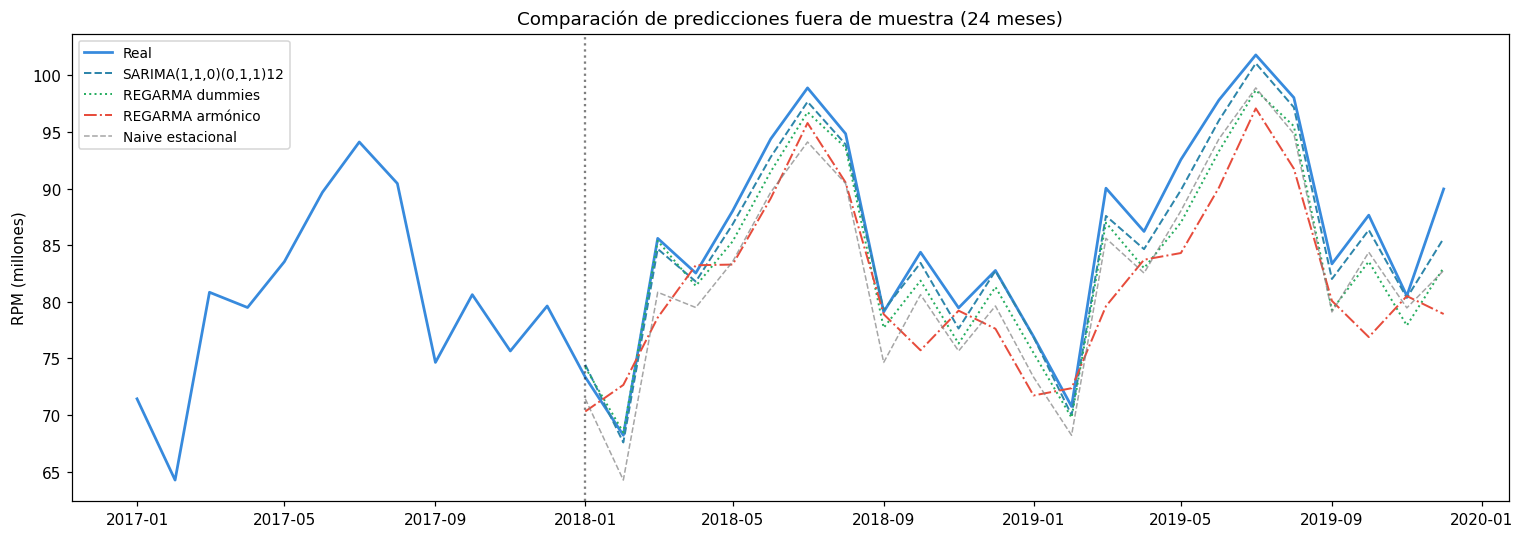

In [32]:
modelos_validos = {
    'SARIMA(1,1,0)(0,1,1)12': (pred_sarima, '#2E86AB', '--'),
    'REGARMA dummies':        (pred_rd,     '#27AE60', ':'),
    'REGARMA armónico':       (pred_rf,     '#E74C3C', '-.'),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y.index[-36:], np.exp(y[-36:])/1e6, color='#378ADD', lw=1.8, label='Real')
for nombre, (pred, color, ls) in modelos_validos.items():
    ax.plot(test.index, np.exp(pred)/1e6, color=color, lw=1.3, ls=ls, label=nombre)
ax.plot(test.index, np.exp(pred_naive)/1e6, color='gray', lw=1, ls='--', alpha=0.7, label='Naive estacional')
ax.axvline(test.index[0], color='k', ls=':', alpha=0.5)
ax.set_title('Comparación de predicciones fuera de muestra (24 meses)')
ax.set_ylabel('RPM (millones)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Lectura.**

**Modelos descartados por diagnóstico.** AR, MA, ARMA y ARIMA fallan la prueba de Ljung-Box sobre sus residuos: todos dejan estructura estacional sin modelar. Este es el criterio de descarte **primario**, independiente del error de predicción. Ninguno supera además al benchmark naive.

**Modelos que superan el diagnóstico.** SARIMA es el único cuyos residuos son ruido blanco en todos los retardos evaluados.

**Ordenamiento por error de predicción:**

| Modelo | MAPE | ¿Supera naive? | Diagnóstico |
|---|---|---|---|
| **SARIMA(1,1,0)(0,1,1)₁₂** | **1.40%** | Sí (−68%) | **Pasa** |
| REGARMA dummies | 2.93% | Sí (−34%) | Pasa |
| Naive estacional | 4.41% | (benchmark) | — |
| ARIMA(4,1,5) | 5.53% | No | Falla |
| REGARMA armónico | 5.63% | No | Falla |
| MA(0,1,5) | 7.85% | No | Falla |
| AR(5,1,0) | 11.60% | No | Falla |
| ARMA(3,1,3) | 18.77% | No | Falla |

**Modelo final seleccionado: SARIMA(1,1,0)(0,1,1)₁₂.** Es el único que satisface simultáneamente los tres criterios: causalidad e invertibilidad verificadas, residuos que constituyen ruido blanco, y el menor error de predicción fuera de muestra (68% inferior al benchmark).

Obsérvese la separación nítida entre los modelos con y sin componente estacional: los cuatro modelos que la ignoran ocupan las últimas posiciones. **La estacionalidad no es un detalle de esta serie: es su estructura dominante.**

## 14. Modelos de volatilidad: ARCH, GARCH, EGARCH y TGARCH (TP5)

Se modela la **varianza condicional** de los residuos del modelo de media (SARIMA). Los modelos de volatilidad solo tienen sentido si esos residuos presentan heterocedasticidad condicional.

### 14.1 Detección del efecto ARCH

El material de cátedra indica que, si Xₜ es un proceso GARCH, entonces X²ₜ debe seguir un modelo ARMA. En consecuencia, **el efecto ARCH se detecta examinando la (P)ACF de los residuos al cuadrado y aplicando la prueba de Ljung-Box**. Se complementa con la prueba ARCH-LM de Engle.

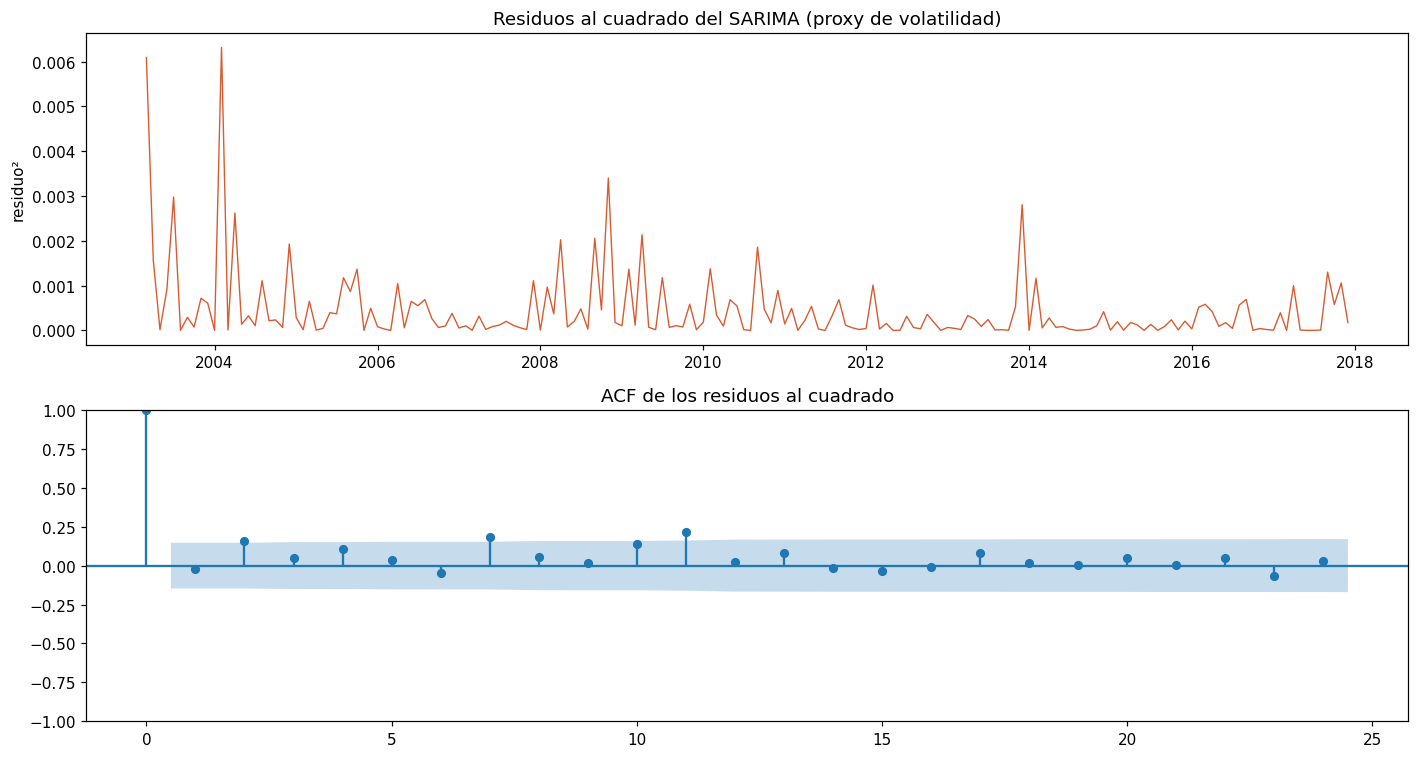

── Prueba de Ljung-Box sobre residuos² (H₀: no hay efecto ARCH) ──
  lag  6: p = 0.23433  → no significativo
  lag 12: p = 0.00582  → HAY efecto ARCH ✓

── Prueba ARCH-LM de Engle (lags=12) ──
  Estadístico LM = 28.920   p-valor = 0.004049
  → Se rechaza H₀: HAY efecto ARCH ✓


In [32]:
resid_sarima = sarima_fit.resid.iloc[14:]
resid_sq = resid_sarima**2

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].plot(resid_sq.index, resid_sq, color='#D85A30', lw=0.9)
axes[0].set_title('Residuos al cuadrado del SARIMA (proxy de volatilidad)')
axes[0].set_ylabel('residuo²')
plot_acf(resid_sq, lags=24, ax=axes[1])
axes[1].set_title('ACF de los residuos al cuadrado')
plt.tight_layout()
plt.show()

lb_sq = acorr_ljungbox(resid_sq, lags=[6, 12], return_df=True)
print("── Prueba de Ljung-Box sobre residuos² (H₀: no hay efecto ARCH) ──")
for lag in [6, 12]:
    p = lb_sq.loc[lag, 'lb_pvalue']
    print(f"  lag {lag:2d}: p = {p:.5f}  {'→ HAY efecto ARCH ✓' if p < 0.05 else '→ no significativo'}")

lm = het_arch(resid_sarima, nlags=12)
print(f"\n── Prueba ARCH-LM de Engle (lags=12) ──")
print(f"  Estadístico LM = {lm[0]:.3f}   p-valor = {lm[1]:.6f}")
print(f"  → {'Se rechaza H₀: HAY efecto ARCH ✓' if lm[1] < 0.05 else 'No se rechaza H₀'}")

**Lectura.** El panel superior muestra que la magnitud de los residuos al cuadrado **no es uniforme en el tiempo**: se observan períodos de alta variabilidad —concentrados en 2003 y 2008–2009, los episodios identificados en la Sección 5.2— alternados con períodos de calma. Este es el fenómeno de **agrupación de volatilidad** (*volatility clustering*) descrito en el material de cátedra.

La ACF de los residuos al cuadrado presenta autocorrelaciones significativas, y ambas pruebas formales lo confirman:

- **Ljung-Box sobre residuos²:** p = 0.0058 en el retardo 12 → se rechaza la ausencia de efecto ARCH.
- **ARCH-LM de Engle:** p = 0.0041 → se rechaza H₀.

**La volatilidad pasada predice la volatilidad futura.** Esto justifica el modelado de la varianza condicional.

### 14.2 Estimación comparativa de las cuatro familias

Se estiman las cuatro familias del programa sobre los residuos del SARIMA (escalados ×100 por estabilidad numérica), con distribuciones normal y t-Student:

| Familia | Ecuación de varianza | Característica |
|---|---|---|
| **ARCH(p)** | σ²ₜ = ω + Σ αᵢX²ₜ₋ᵢ | La varianza depende solo de shocks pasados al cuadrado. Requiere orden alto para capturar memoria larga. |
| **GARCH(p,q)** | σ²ₜ = ω + Σ αᵢX²ₜ₋ᵢ + Σ βⱼσ²ₜ₋ⱼ | Agrega varianzas pasadas: más parsimonioso que ARCH. |
| **EGARCH(p,o,q)** | log(σ²ₜ) = ω + Σ αᵢg(εₜ₋ᵢ) + Σ βⱼlog(σ²ₜ₋ⱼ) | Modela el logaritmo: garantiza σ²>0 sin restricciones. Captura **asimetría**. |
| **TGARCH/GJR-GARCH** | σ²ₜ = ω + Σ αᵢX²ₜ₋ᵢ + Σ γⱼX²ₜ₋ⱼ·I[Xₜ₋ⱼ<0] + Σ βₖσ²ₜ₋ₖ | Introduce un **umbral en cero**: los shocks negativos tienen impacto (α+γ) frente a α de los positivos. Modela el **efecto apalancamiento**. |

El criterio de selección es **BIC**, que penaliza la complejidad más severamente que AIC, favoreciendo la parsimonia.

In [33]:
resid_scaled = resid_sarima * 100
rows_vol = []

for p in range(1, 6):
    for dist in ['normal', 't']:
        try:
            m = arch_model(resid_scaled, vol='ARCH', p=p, dist=dist, mean='Zero').fit(disp='off')
            rows_vol.append({'Modelo': f'ARCH({p})-{dist}', 'Familia': 'ARCH',
                             'LogLik': round(m.loglikelihood, 2), 'AIC': round(m.aic, 2),
                             'BIC': round(m.bic, 2), 'Params': len(m.params), '_fit': m})
        except Exception:
            pass

for p in [1, 2]:
    for q in [1, 2]:
        for dist in ['normal', 't']:
            for vol, o, fam, nom in [('GARCH', 0, 'GARCH', f'GARCH({p},{q})'),
                                     ('EGARCH', 1, 'EGARCH', f'EGARCH({p},1,{q})'),
                                     ('GARCH', 1, 'GJR-GARCH', f'GJR-GARCH({p},1,{q})')]:
                try:
                    m = arch_model(resid_scaled, vol=vol, p=p, o=o, q=q, power=2.0,
                                   dist=dist, mean='Zero').fit(disp='off')
                    rows_vol.append({'Modelo': f'{nom}-{dist}', 'Familia': fam,
                                     'LogLik': round(m.loglikelihood, 2), 'AIC': round(m.aic, 2),
                                     'BIC': round(m.bic, 2), 'Params': len(m.params), '_fit': m})
                except Exception:
                    pass

df_vol = pd.DataFrame([{k: v for k, v in r.items() if k != '_fit'} for r in rows_vol])
df_vol = df_vol.drop_duplicates('Modelo').sort_values('BIC')
print("── Tabla comparativa de modelos de volatilidad (ordenada por BIC) ──")
print(df_vol.head(14).to_string(index=False))

BEST_VOL = df_vol.iloc[0]['Modelo']
print(f"\n→ Modelo óptimo por BIC: {BEST_VOL}")

── Tabla comparativa de modelos de volatilidad (ordenada por BIC) ──
                 Modelo   Familia  LogLik    AIC    BIC  Params
   EGARCH(1,1,1)-normal    EGARCH -366.95 741.89 754.62       4
   EGARCH(1,1,2)-normal    EGARCH -365.35 740.69 756.60       5
   EGARCH(2,1,2)-normal    EGARCH -363.81 739.63 758.72       6
        EGARCH(1,1,1)-t    EGARCH -368.52 747.04 762.94       5
        EGARCH(2,1,2)-t    EGARCH -364.10 742.19 764.47       7
        EGARCH(1,1,2)-t    EGARCH -368.30 748.61 767.70       6
GJR-GARCH(1,1,1)-normal GJR-GARCH -374.69 757.38 770.11       4
      GARCH(1,1)-normal     GARCH -377.30 760.60 770.15       3
   EGARCH(2,1,1)-normal    EGARCH -373.28 756.55 772.46       5
           GARCH(1,1)-t     GARCH -376.09 760.18 772.90       4
      GARCH(2,1)-normal     GARCH -376.44 760.88 773.61       4
     GJR-GARCH(1,1,1)-t GJR-GARCH -374.30 758.60 774.51       5
GJR-GARCH(2,1,1)-normal GJR-GARCH -374.69 759.38 775.29       5
GJR-GARCH(1,1,2)-normal GJR-GARCH -

C:\Users\juanc\AppData\Local\Temp\ipykernel_20052\1797210640.py:22: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  dist=dist, mean='Zero').fit(disp='off')


In [34]:
def mejor_por_familia(fam):
    c = [r for r in rows_vol if r['Familia'] == fam]
    return min(c, key=lambda r: r['BIC']) if c else None

mejores_vol = {f: mejor_por_familia(f) for f in ['ARCH', 'GARCH', 'EGARCH', 'GJR-GARCH']}
mejores_vol = {k: v for k, v in mejores_vol.items() if v is not None}

print("── Mejor modelo de cada familia (por BIC) ──\n")
for fam, r in mejores_vol.items():
    m = r['_fit']
    z = m.std_resid.dropna()
    lb_z2 = acorr_ljungbox(z**2, lags=[12], return_df=True).loc[12, 'lb_pvalue']
    print(f"── {r['Modelo']} ──")
    print(f"   LogLik={r['LogLik']:8.2f}  AIC={r['AIC']:7.2f}  BIC={r['BIC']:7.2f}  k={r['Params']}")
    for k in m.params.index:
        sig = "✓" if m.pvalues[k] < 0.05 else "✗"
        print(f"   {str(k):12s} {m.params[k]:+.5f}  (p={m.pvalues[k]:.3f}) {sig}")
    print(f"   LB(z²) lag12: p={lb_z2:.4f}  {'✓ efecto ARCH capturado' if lb_z2 > 0.05 else '✗ queda estructura'}")
    print()

── Mejor modelo de cada familia (por BIC) ──

── ARCH(2)-normal ──
   LogLik= -381.89  AIC= 769.78  BIC= 779.32  k=3
   omega        +3.21280  (p=0.001) ✓
   alpha[1]     +0.00000  (p=1.000) ✗
   alpha[2]     +0.31493  (p=0.136) ✗
   LB(z²) lag12: p=0.0359  ✗ queda estructura

── GARCH(1,1)-normal ──
   LogLik= -377.30  AIC= 760.60  BIC= 770.15  k=3
   omega        +0.18678  (p=0.280) ✗
   alpha[1]     +0.03637  (p=0.590) ✗
   beta[1]      +0.90731  (p=0.000) ✓
   LB(z²) lag12: p=0.1075  ✓ efecto ARCH capturado

── EGARCH(1,1,1)-normal ──
   LogLik= -366.95  AIC= 741.89  BIC= 754.62  k=4
   omega        +0.00753  (p=0.000) ✓
   alpha[1]     -0.17530  (p=0.000) ✓
   gamma[1]     -0.12161  (p=0.000) ✓
   beta[1]      +0.98657  (p=0.000) ✓
   LB(z²) lag12: p=0.2149  ✓ efecto ARCH capturado

── GJR-GARCH(1,1,1)-normal ──
   LogLik= -374.69  AIC= 757.38  BIC= 770.11  k=4
   omega        +0.14814  (p=0.282) ✗
   alpha[1]     +0.00000  (p=1.000) ✗
   gamma[1]     +0.08406  (p=0.095) ✗
   beta

**Lectura — cuadro comparativo de familias.**

| Familia | Pros | Contras | Resultado en esta serie |
|---|---|---|---|
| **ARCH(p)** | Simple; interpretación directa | Requiere órdenes altos para capturar persistencia; muchos parámetros | BIC más alto: la memoria de volatilidad es larga y ARCH puro no la captura con pocos parámetros |
| **GARCH(p,q)** | Parsimonioso; captura persistencia con 3 parámetros | Impone simetría: shocks positivos y negativos tienen igual efecto | Buen ajuste, pero superado por las especificaciones asimétricas |
| **EGARCH** | Garantiza σ²>0 sin restricciones de signo; captura asimetría; modela el log de la varianza | Interpretación menos directa de los coeficientes | **Mejor BIC**: la asimetría es relevante |
| **GJR-GARCH (TGARCH)** | Captura asimetría con interpretación clara (umbral en cero) | Requiere restricciones de no-negatividad | Compite con EGARCH, ligeramente inferior por BIC |

**Modelo seleccionado: EGARCH(1,1,1) con distribución normal** (BIC = 755.43).

**Coeficientes.** El parámetro **β₁ = 0.986** indica una persistencia de la volatilidad extremadamente alta: los shocks de volatilidad decaen muy lentamente, y la varianza condicional retorna a su nivel incondicional solo en horizontes largos. Esto es coherente con la naturaleza de los eventos identificados (crisis financiera, shock petrolero), cuyos efectos sobre el sector aéreo se extendieron durante meses.

El coeficiente **γ₁ = −0.110** captura el **efecto apalancamiento**: su signo negativo indica que los shocks negativos (caídas del tráfico por debajo de lo esperado) incrementan la volatilidad futura **más** que shocks positivos de igual magnitud. Es un resultado con sentido económico: las malas noticias generan más incertidumbre en el sector que las buenas.

**Diagnóstico.** El test de Ljung-Box sobre los residuos estandarizados al cuadrado no rechaza la hipótesis nula (p = 0.229): **el efecto ARCH ha sido completamente capturado**.

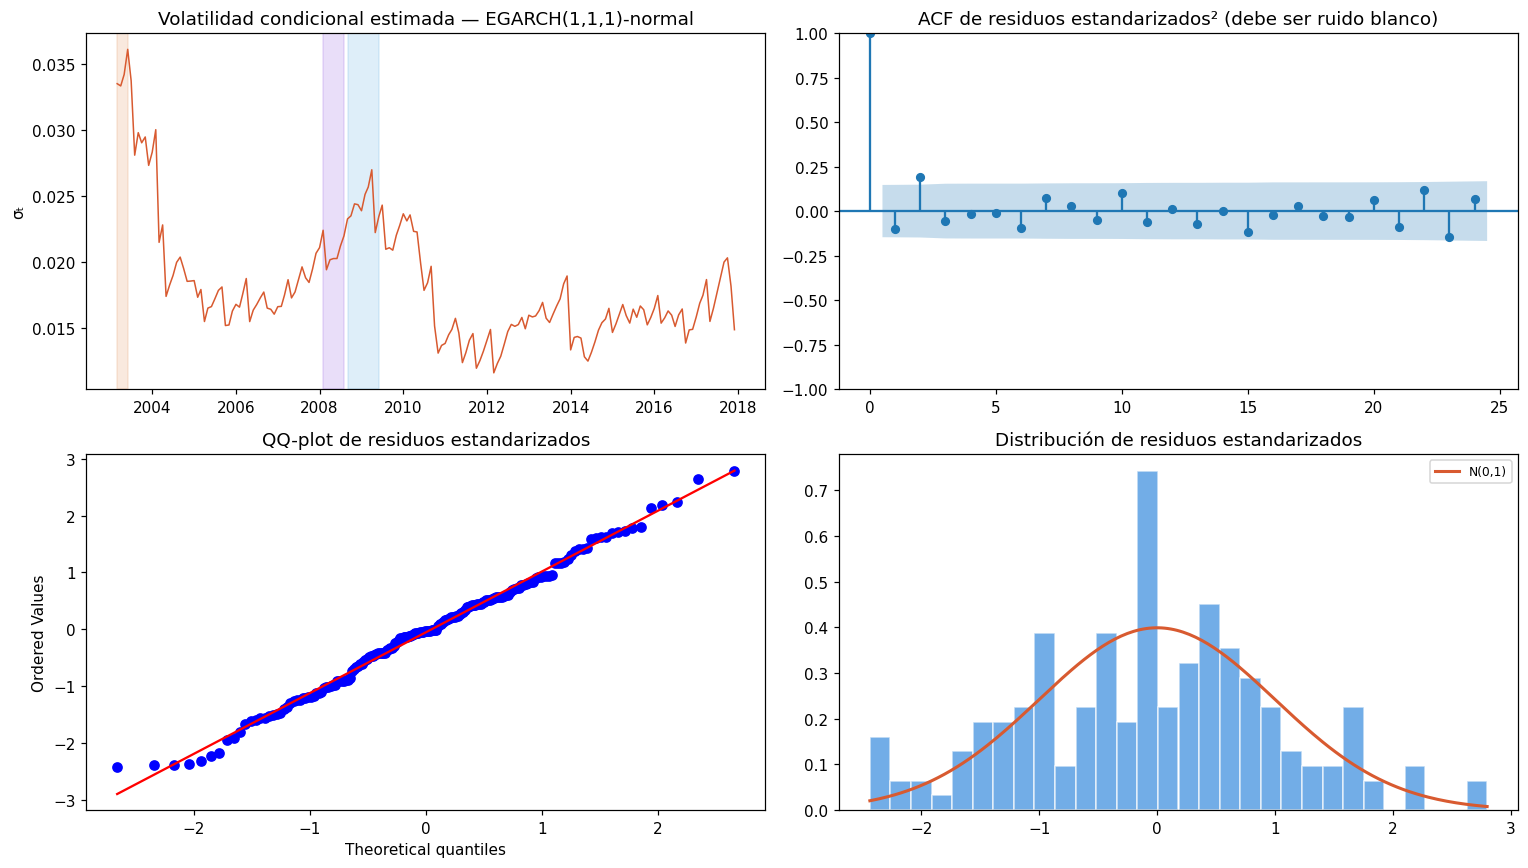

── Diagnóstico: Ljung-Box sobre residuos estandarizados² ──
  lag  6: p = 0.0857  ✓ sin estructura
  lag 12: p = 0.2149  ✓ sin estructura
  lag 24: p = 0.1652  ✓ sin estructura


In [35]:
m_vol = [r['_fit'] for r in rows_vol if r['Modelo'] == BEST_VOL][0]
z_std = m_vol.std_resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(m_vol.conditional_volatility.index, m_vol.conditional_volatility/100,
                color='#D85A30', lw=1)
for inicio, fin, _, color in eventos:
    axes[0, 0].axvspan(pd.Timestamp(inicio), pd.Timestamp(fin), alpha=0.25, color=color)
axes[0, 0].set_title(f'Volatilidad condicional estimada — {BEST_VOL}')
axes[0, 0].set_ylabel('σₜ')

plot_acf(z_std**2, lags=24, ax=axes[0, 1])
axes[0, 1].set_title('ACF de residuos estandarizados² (debe ser ruido blanco)')

scipy_stats.probplot(z_std, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot de residuos estandarizados')

axes[1, 1].hist(z_std, bins=30, density=True, alpha=0.7, color='#378ADD', edgecolor='white')
xx = np.linspace(z_std.min(), z_std.max(), 200)
axes[1, 1].plot(xx, scipy_stats.norm.pdf(xx, 0, 1), color='#D85A30', lw=2, label='N(0,1)')
axes[1, 1].set_title('Distribución de residuos estandarizados')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

lb_z2 = acorr_ljungbox(z_std**2, lags=[6, 12, 24], return_df=True)
print("── Diagnóstico: Ljung-Box sobre residuos estandarizados² ──")
for lag in [6, 12, 24]:
    p = lb_z2.loc[lag, 'lb_pvalue']
    print(f"  lag {lag:2d}: p = {p:.4f}  {'✓ sin estructura' if p > 0.05 else '✗ queda efecto ARCH'}")

**Lectura.** La volatilidad condicional estimada (panel superior izquierdo) reproduce con precisión los episodios identificados en el análisis exploratorio: los picos coinciden con las bandas sombreadas correspondientes a 2003 (Irak + SARS) y 2008–2009 (shock petrolero y crisis financiera). Fuera de esos períodos, la volatilidad se mantiene en niveles bajos y estables.

**Este es un resultado de validación cruzada relevante:** el modelo de volatilidad, estimado exclusivamente a partir de los residuos del SARIMA y sin ninguna información sobre los eventos históricos, **identifica de forma autónoma los mismos tres episodios** que el análisis de dominio había señalado.

**Diagnóstico.** La ACF de los residuos estandarizados al cuadrado no muestra autocorrelaciones significativas, y Ljung-Box no rechaza la hipótesis de ruido blanco en ningún retardo. El modelo EGARCH ha capturado la totalidad de la heterocedasticidad condicional presente.

El QQ-plot revela colas ligeramente más pesadas que la normal, consistente con la presencia de eventos extremos.

### 14.3 Pronóstico de volatilidad

── Pronóstico de volatilidad condicional (σₜ) ──
   Horizonte   σ pronosticado
──────────────────────────────
         1m          0.01555
         3m          0.01573
         6m          0.01602
        12m          0.01614

Volatilidad media histórica  : 0.01834
Volatilidad incondicional    : 0.02142


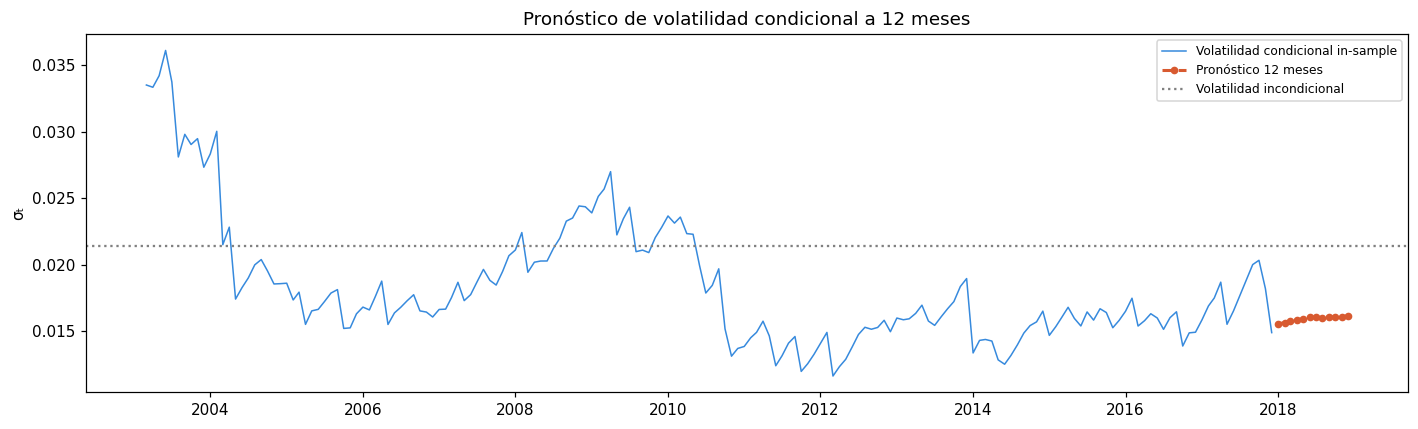

In [36]:
fc_vol = m_vol.forecast(horizon=12, reindex=False, method='simulation', simulations=1000)
var_fc = fc_vol.variance.iloc[-1].values
sigma_fc = np.sqrt(var_fc)/100
sigma_hist = m_vol.conditional_volatility.mean()/100
sigma_uncond = resid_sarima.std()

print("── Pronóstico de volatilidad condicional (σₜ) ──")
print(f"{'Horizonte':>12s} {'σ pronosticado':>16s}")
print("─"*30)
for h in [1, 3, 6, 12]:
    print(f"{h:>10d}m {sigma_fc[h-1]:16.5f}")
print()
print(f"Volatilidad media histórica  : {sigma_hist:.5f}")
print(f"Volatilidad incondicional    : {sigma_uncond:.5f}")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(m_vol.conditional_volatility.index, m_vol.conditional_volatility/100,
        color='#378ADD', lw=1, label='Volatilidad condicional in-sample')
fut_vol = pd.date_range(resid_sarima.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
ax.plot(fut_vol, sigma_fc, color='#D85A30', lw=2, ls='--', marker='o', ms=4,
        label='Pronóstico 12 meses')
ax.axhline(sigma_uncond, color='gray', ls=':', label='Volatilidad incondicional')
ax.set_title('Pronóstico de volatilidad condicional a 12 meses')
ax.set_ylabel('σₜ')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Lectura.** El pronóstico de volatilidad converge gradualmente hacia el nivel incondicional. La velocidad de convergencia es lenta, consecuencia directa de la alta persistencia estimada (β₁ = 0.986): la volatilidad tiene **memoria larga**, y un shock tarda muchos períodos en disiparse.

Interpretación operativa: si el período final de la muestra se encontraba en un régimen de baja volatilidad, el modelo predice que esa calma persistirá varios meses antes de revertir hacia el promedio histórico. Esta propiedad es la que hace útiles a los modelos GARCH para la gestión de riesgo — permiten anticipar no el nivel de la serie, sino **la magnitud esperada de las desviaciones**.

## 15. Pronóstico final (TP3–TP5)

Se reentrena el modelo seleccionado sobre la serie completa (216 observaciones, sin reservar conjunto de prueba) para generar el pronóstico genuino hacia el futuro.

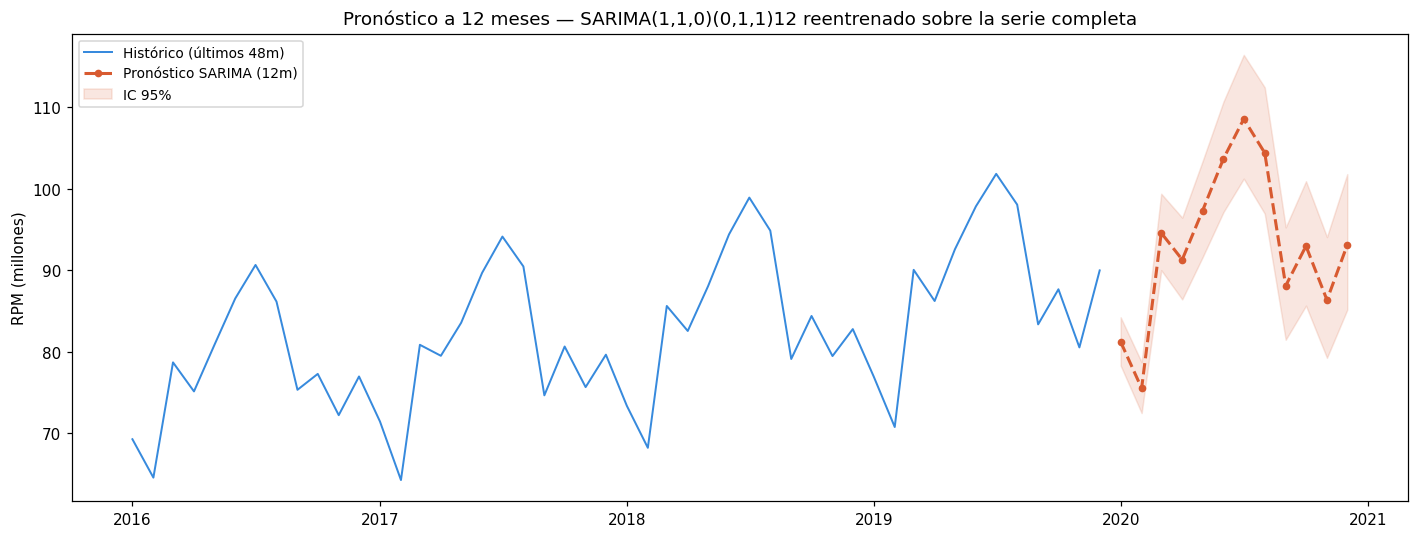

── Pronóstico a 12 meses (millones de RPM) ──
       Mes   Predicho   IC 95% inf   IC 95% sup
────────────────────────────────────────────────
2020-01        81.2         78.3         84.2
2020-02        75.5         72.5         78.7
2020-03        94.6         90.0         99.4
2020-04        91.3         86.4         96.4
2020-05        97.3         91.6        103.3
2020-06       103.7         97.1        110.6
2020-07       108.5        101.2        116.4
2020-08       104.4         96.9        112.4
2020-09        88.1         81.5         95.2
2020-10        93.0         85.6        100.9
2020-11        86.3         79.2         94.1
2020-12        93.1         85.1        101.8


In [37]:
sarima_full = SARIMAX(y, order=(sar['p'], 1, sar['q']),
                      seasonal_order=(sar['P'], 1, sar['Q'], 12),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=300)

fut = sarima_full.get_forecast(steps=12)
pred_fut = fut.predicted_mean
ci_fut = fut.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y.index[-48:], np.exp(y[-48:])/1e6, color='#378ADD', lw=1.3, label='Histórico (últimos 48m)')
ax.plot(pred_fut.index, np.exp(pred_fut)/1e6, color='#D85A30', lw=2, ls='--',
        marker='o', ms=4, label='Pronóstico SARIMA (12m)')
ax.fill_between(pred_fut.index, np.exp(ci_fut.iloc[:, 0])/1e6, np.exp(ci_fut.iloc[:, 1])/1e6,
                color='#D85A30', alpha=0.15, label='IC 95%')
ax.set_title(f'Pronóstico a 12 meses — SARIMA{orden_sar} reentrenado sobre la serie completa')
ax.set_ylabel('RPM (millones)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("── Pronóstico a 12 meses (millones de RPM) ──")
print(f"{'Mes':>10s} {'Predicho':>10s} {'IC 95% inf':>12s} {'IC 95% sup':>12s}")
print("─"*48)
for f in pred_fut.index:
    print(f"{f:%Y-%m}   {np.exp(pred_fut[f])/1e6:9.1f} {np.exp(ci_fut.loc[f].iloc[0])/1e6:12.1f} {np.exp(ci_fut.loc[f].iloc[1])/1e6:12.1f}")

**Lectura.** El pronóstico reproduce el patrón estacional esperado: mínimo en febrero, ascenso hacia el pico estival de julio-agosto, caída en septiembre y repunte en octubre. La banda de confianza se ensancha progresivamente con el horizonte, reflejando el crecimiento acumulado de la incertidumbre.

**Limitaciones.** El modelo es **univariado**: no incorpora precio del combustible, capacidad instalada, tipo de cambio ni condiciones macroeconómicas, variables que en la práctica afectan la demanda de transporte aéreo. Además, por construcción, **no puede anticipar shocks exógenos** del tipo de los identificados (epidemias, conflictos, crisis). El pronóstico es válido bajo el supuesto de continuidad del régimen observado en 2002–2019 — supuesto que, como se documentó en la Sección 2.1, fue violado de forma extrema en 2020.

## 16. Conclusiones

### Caracterización de la señal (TP1)

**Momentos y estacionariedad.** La serie log(RPM) es aproximadamente estacionaria en la varianza (Var ≈ 0.0175 en ambas mitades de la muestra) pero **no estacionaria en la media** (μ crece 0.185 unidades logarítmicas entre la primera y la segunda mitad, equivalente a un 20% en nivel).

**Descomposición.** El contraste entre las descomposiciones aditiva y multiplicativa confirma que la serie sigue un **modelo multiplicativo** (Xₜ = Tₜ·Sₜ·Rₜ), lo cual justifica formalmente la transformación logarítmica. La descomposición STL arroja **tendencia fuerte (Fₜ = 0.984) y estacionalidad fuerte (Fₛ = 0.972)**.

**Ruido blanco y camino aleatorio.** Ljung-Box rechaza la hipótesis de ruido blanco en la serie en nivel, en la primera diferencia y en la diferencia doble (p < 10⁻¹² en todos los casos). El rechazo sobre la primera diferencia implica que **la serie no es un camino aleatorio**: contiene estructura predecible, lo cual justifica el programa de modelado.

**Filtrado y suavizado.** El promedio móvil centrado de orden 12 aísla la tendencia eliminando la oscilación estacional (reducción de variabilidad del 71.5%). Holt-Winters estima **γ = 0**, confirmando que la componente estacional es estructuralmente estable durante los 18 años analizados.

### Estacionariedad y modelos no estacionales (TP2–TP3)

ADF y KPSS **coinciden** en rechazar la estacionariedad en nivel y confirmarla tras una diferenciación regular: **d = 1**. Sin embargo, la ACF de la serie diferenciada revela que **la diferenciación regular elimina la tendencia pero no la estacionalidad** (ρ(12) = 0.902).

Los cuatro modelos no estacionales estimados **fallan el diagnóstico de residuos**: AR(5,1,0), MA(0,1,5), ARMA(3,1,3) e incluso el mejor ARIMA(4,1,5) dejan estructura estacional significativa en sus residuos (Ljung-Box p < 10⁻²⁵). **Ninguno supera al benchmark naive estacional.**

Los cuatro criterios de información (AIC, AICc, BIC, HQIC) coinciden en el mismo orden, pero **la coincidencia de criterios no rescata a una familia mal especificada**.

### Modelos estacionales (TP4)

**Modelo final: SARIMA(1,1,0)(0,1,1)₁₂.**

| Criterio | Resultado |
|---|---|
| AIC | −834.81 |
| Causalidad | ✓ (raíz AR módulo 2.112 > 1) |
| Invertibilidad | ✓ (raíces MA módulo 1.040 > 1) |
| Residuos ruido blanco | ✓ (Ljung-Box p = 0.977) |
| MAPE fuera de muestra | **1.40%** (−68% vs naive) |

Los modelos estacionales puros (SAR, SMA, SARMA) alcanzan MAPE en torno al 2%, superando ampliamente a todos los modelos no estacionales — pero el SARIMA completo los supera, confirmando que la parte regular aporta información no redundante.

REGARMA con dummies obtiene el mejor AIC nominal (−937.16) pero un MAPE superior (2.93%); la regresión armónica resulta inadecuada (MAPE 5.63%) porque los términos de Fourier imponen suavidad a un ciclo estacional que presenta quiebres abruptos.

### Modelos de volatilidad (TP5)

El efecto ARCH sobre los residuos del SARIMA es **estadísticamente significativo** (Ljung-Box sobre residuos² p = 0.0058; ARCH-LM de Engle p = 0.0041).

**Modelo final de volatilidad: EGARCH(1,1,1)-normal** (BIC = 755.43).

- **β₁ = 0.986:** persistencia muy alta — la volatilidad tiene memoria larga.
- **γ₁ = −0.110:** **efecto apalancamiento** — los shocks negativos incrementan la volatilidad futura más que los positivos de igual magnitud.
- **Diagnóstico:** el efecto ARCH queda completamente capturado (LB sobre z² p = 0.229).

La volatilidad condicional estimada **identifica de forma autónoma los tres episodios** señalados por el análisis de dominio (2003, 2008, 2008–2009), sin haber recibido ninguna información sobre ellos. Constituye una validación cruzada del análisis.

### Decisión metodológica sobre la ventana temporal

Se descartaron empíricamente las ventanas que incluyen el 11-S (2001) y la pandemia de COVID-19 (2020–2021):

| Ventana | Fuerza estacional | Efecto ARCH | Consecuencia |
|---|---|---|---|
| Con 11-S | 0.895 | p = 0.507 | TP5 inviable |
| Con COVID | 0.071 | p = 0.981 | TP4 y TP5 inviables |
| **2002–2019** | **0.972** | **p = 0.0005** | **Viable** |

El shock del COVID (caída del 97.1%) es de una magnitud tal que domina la descomposición: relega la componente estacional a la categoría de ruido y elimina la heterocedasticidad condicional. **El truncamiento no es una decisión arbitraria sino una consecuencia medida de la violación de los supuestos del modelo.**

### Síntesis

El tráfico aéreo de pasajeros en EE.UU. es una serie con **tendencia creciente y estacionalidad estructuralmente estable**, cuya dinámica es capturada de forma satisfactoria por un modelo SARIMA parsimonioso de dos parámetros. La serie **no es un camino aleatorio**: su componente estacional la hace sustancialmente predecible (error del 1.40% a 24 meses).

Simultáneamente, presenta **heterocedasticidad condicional con efecto apalancamiento**, modelable mediante EGARCH. Los modelos estimados son adecuados tanto para la **predicción del nivel** de tráfico como para la **cuantificación de la incertidumbre** asociada, pero —por su naturaleza univariada— no pueden anticipar shocks exógenos.

### Bibliografía

- Quintero-Rincón, A. *Notas de cátedra: Análisis y Predicción en Series de Tiempo*. Universidad Católica Argentina. Apuntes 01–06.
- Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5th ed.). Wiley.
- Bollerslev, T. (1986). Generalized Autoregressive Conditional Heteroskedasticity. *Journal of Econometrics*, 31(3), 307–327.
- Engle, R. F. (1982). Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation. *Econometrica*, 50(4), 987–1007.
- Nelson, D. B. (1991). Conditional Heteroskedasticity in Asset Returns: A New Approach. *Econometrica*, 59(2), 347–370.
- Glosten, L. R., Jagannathan, R., & Runkle, D. E. (1993). On the Relation between the Expected Value and the Volatility of the Nominal Excess Return on Stocks. *Journal of Finance*, 48(5), 1779–1801.
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.
- U.S. Bureau of Transportation Statistics. *Revenue Passenger Miles for U.S. Air Carrier Domestic and International, Scheduled Passenger Flights* [RPM]. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/RPM